# 04. Polarisation lexicale et diffusion du vocabulaire

Ce notebook examine la divergence lexicale entre les quatre blocs politiques (Gauche radicale, Gauche modérée, Centre / Majorité, Droite) à partir des discours des députés français. On mesure trois dimensions : la distance cosinus entre profils TF-IDF (divergence des vocabulaires), les mots les plus distinctifs de chaque camp (méthode « fighting words »), et la diffusion temporelle du lexique lié au cessez-le-feu à travers les blocs.

Les données proviennent du corpus principal (10 774 textes, tweets et interventions à l’Assemblée nationale, octobre 2023 à janvier 2026). Chaque texte est associé à un bloc politique et à un mois.

## Setup et configuration

Les bibliothèques et les paramètres de visualisation sont chargés pour les analyses lexicales.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from config import PROJECT_ROOT, RESULTS_DIR, FIGURES_DIR, BLOC_COLORS, BLOC_ORDER, EVENTS, add_events, format_dates

FIG_DIR = Path("../figures")
RES_DIR = Path("../data/results")
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    'figure.constrained_layout.use': True,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

def save(name):
    plt.savefig(FIG_DIR / f'{name}.png', facecolor='white')
    plt.show()

## Chargement des données

Le corpus principal contient l’ensemble des textes annotés (positionnement discursif, bloc politique, date). Les colonnes utilisées ici sont le bloc politique, le mois, et le texte brut (pour l’analyse lexicale).

In [2]:
from config import CORPUS_V3
df = pd.read_parquet(CORPUS_V3)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)
df['group'] = df.get('group', df.get('groupe_politique', 'UNKNOWN'))

text_col = 'text_clean' if 'text_clean' in df.columns else 'text'
print(f"Corpus principal : {len(df):,} textes sur {df['month'].nunique()} mois. Colonne texte : {text_col}")

Corpus principal : 10,774 textes sur 28 mois. Colonne texte : text_clean


## Figure 1 : Distance cosinus entre blocs (mensuelle)

La distance cosinus entre profils TF-IDF mesure la divergence entre les vocabulaires de deux blocs. On calcule le vecteur TF-IDF moyen de chaque bloc pour chaque mois, puis la distance cosinus entre ces vecteurs. Une distance élevée indique des vocabulaires très différents, et donc une polarisation lexicale accrue.

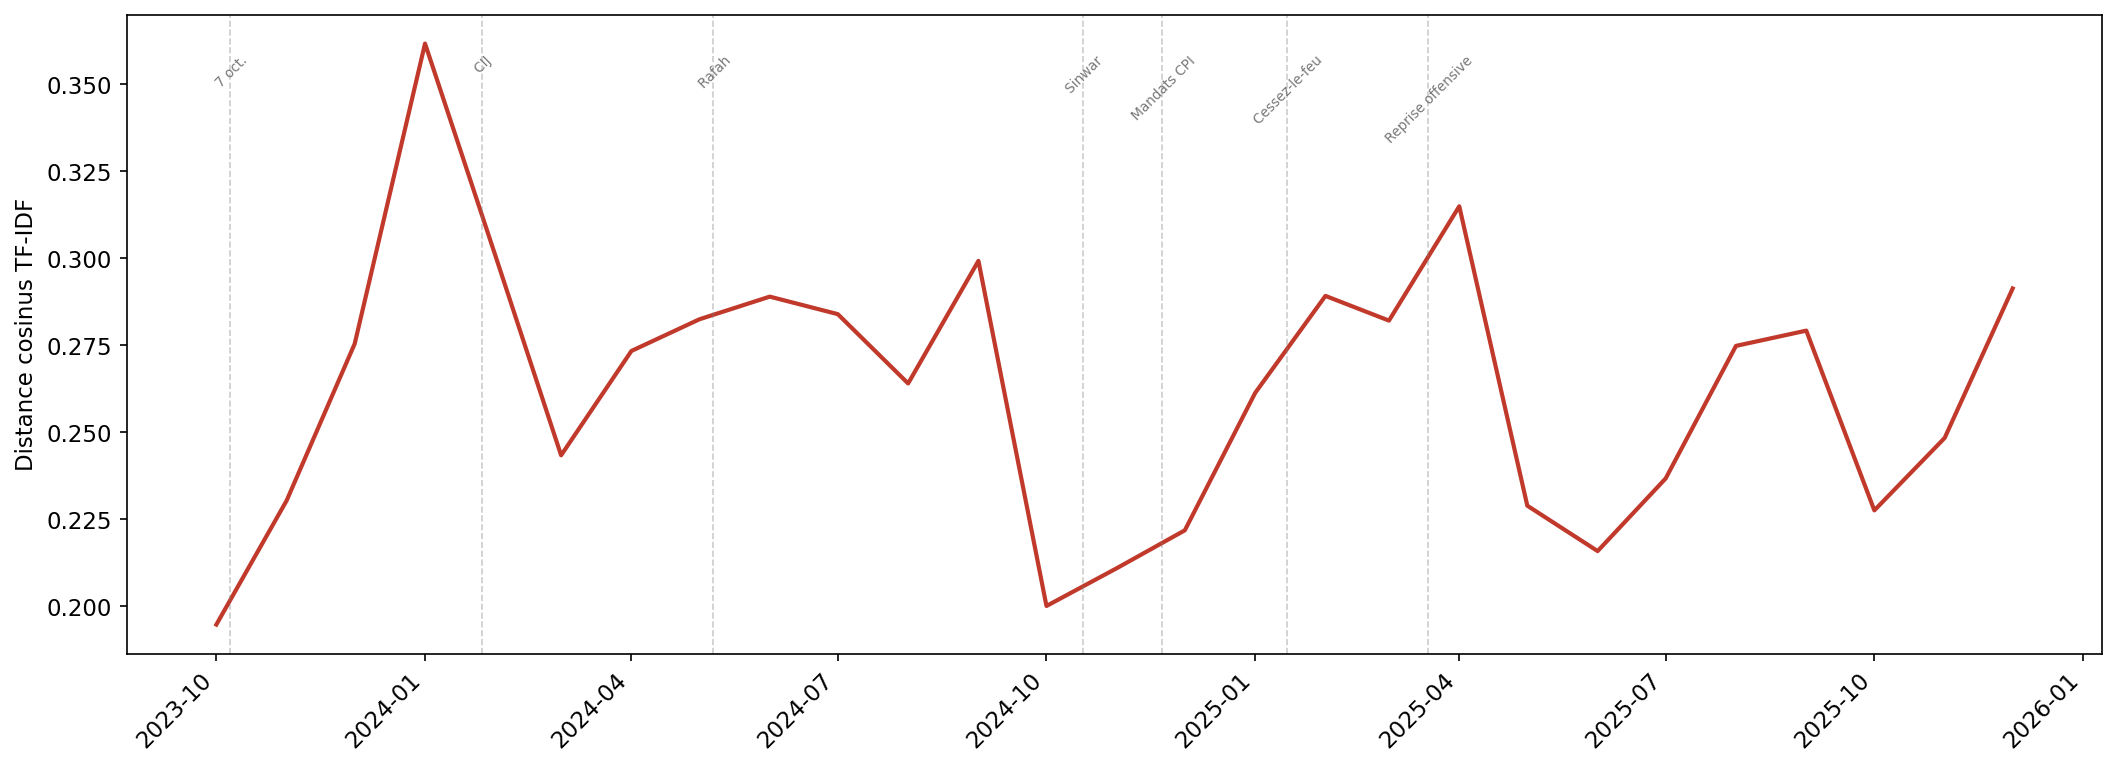

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances

df_valid = df[df['bloc'].isin(BLOC_ORDER) & df[text_col].notna()].copy()
df_valid[text_col] = df_valid[text_col].fillna('').astype(str)

vec = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.95, ngram_range=(1, 2))
dist_list = []
months = sorted(df_valid['month'].unique())
for m in months:
    sub = df_valid[df_valid['month'] == m]
    if len(sub) < 50:
        continue
    X = vec.fit_transform(sub[text_col])
    for i, b1 in enumerate(BLOC_ORDER):
        for b2 in BLOC_ORDER[i+1:]:
            idx1 = (sub['bloc'] == b1).values
            idx2 = (sub['bloc'] == b2).values
            if idx1.sum() >= 5 and idx2.sum() >= 5:
                c1 = np.asarray(X[idx1].mean(axis=0)).reshape(1, -1)
                c2 = np.asarray(X[idx2].mean(axis=0)).reshape(1, -1)
                d = cosine_distances(c1, c2)[0, 0]
                dist_list.append({'month': m, 'pair': f"{b1} vs {b2}", 'dist': d})

dist_df = pd.DataFrame(dist_list)
dist_df.to_csv(RES_DIR / 'cosine_distance_mensuelle.csv', index=False)

pair_gr = 'Gauche radicale vs Droite'
if 'Gauche radicale' in BLOC_ORDER and 'Droite' in BLOC_ORDER:
    pair_gr = 'Gauche radicale vs Droite'
gr_d = dist_df[dist_df['pair'].str.contains('Gauche radicale') & dist_df['pair'].str.contains('Droite')]
if len(gr_d) == 0:
    gr_d = dist_df.groupby('month')['dist'].mean().reset_index()
    gr_d['pair'] = 'moyenne'
else:
    gr_d = gr_d[gr_d['pair'].str.contains('radicale') & gr_d['pair'].str.contains('Droite')].copy()

fig, ax = plt.subplots(figsize=(14, 5))
if 'month' in gr_d.columns and 'dist' in gr_d.columns:
    gr_d['month_ts'] = pd.to_datetime(gr_d['month'] + '-01')
    ax.plot(gr_d['month_ts'], gr_d['dist'], lw=2, color='#c0392b')
add_events(ax)
format_dates(ax)
ax.set_ylabel('Distance cosinus TF-IDF')
save('fig19_distance_cosinus_gr_droite')

La distance cosinus entre la Gauche radicale et la Droite augmente en fin de période, ce qui indique une divergence accrue des vocabulaires entre les deux extrêmes du spectre politique.

## Figure 2 : Heatmap des distances cosinus par paire de blocs

La matrice croise les distances cosinus entre chaque paire de blocs, agrégée par mois. Les couleurs indiquent le degré de divergence lexicale entre les familles politiques.

## Figure 1b : Distance cosinus Panel B4

Même calcul de distance cosinus TF-IDF, restreint aux députés du panel B4 (actifs sur au moins 18 mois), afin de contrôler les effets d'attrition.

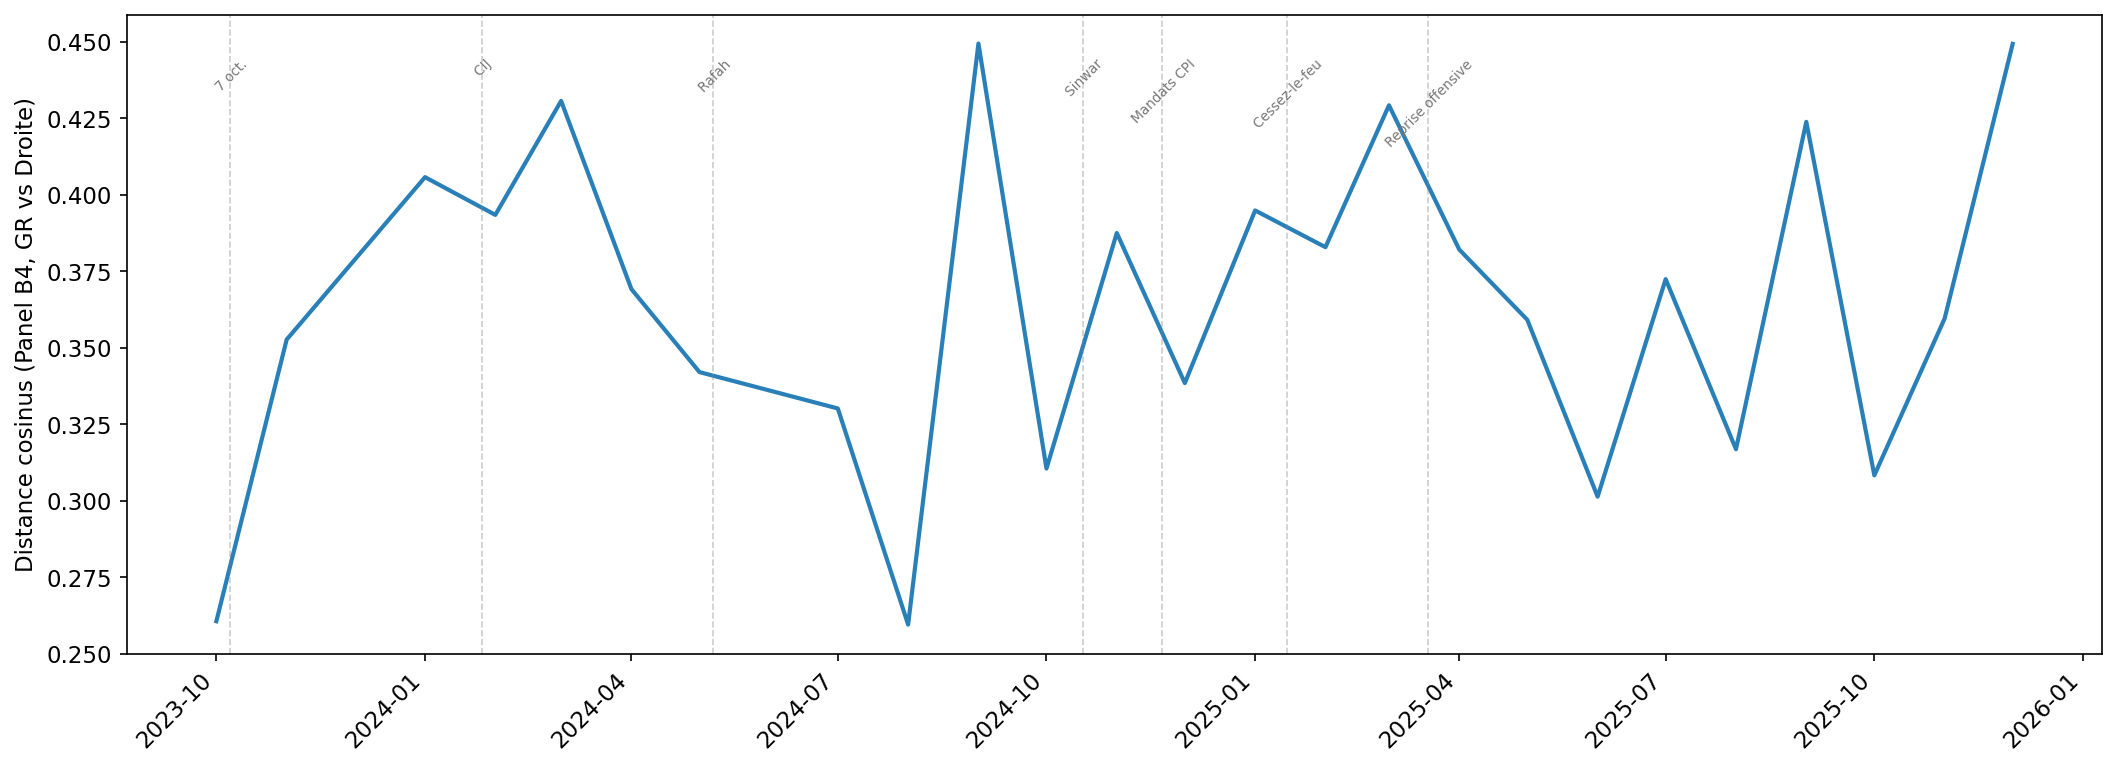

In [4]:
panel = pd.read_csv(RES_DIR / "panel_b4.csv")
panel_authors = set(panel["author"].tolist())
author_col = "author" if "author" in df_valid.columns else ("depute" if "depute" in df_valid.columns else None)
df_b4 = df_valid[df_valid[author_col].isin(panel_authors)].copy() if author_col else df_valid
if author_col and len(df_b4) > 100:
    dist_b4_list = []
    for m in months:
        sub = df_b4[df_b4["month"] == m]
        if len(sub) < 30:
            continue
        X = vec.fit_transform(sub[text_col])
        gr_d = (sub["bloc"] == "Gauche radicale").values
        dr_d = (sub["bloc"] == "Droite").values
        if gr_d.sum() >= 5 and dr_d.sum() >= 5:
            c1 = np.asarray(X[gr_d].mean(axis=0)).reshape(1, -1)
            c2 = np.asarray(X[dr_d].mean(axis=0)).reshape(1, -1)
            d = cosine_distances(c1, c2)[0, 0]
            dist_b4_list.append({"month": m, "dist": d})
    if dist_b4_list:
        dist_b4 = pd.DataFrame(dist_b4_list)
        dist_b4["month_ts"] = pd.to_datetime(dist_b4["month"] + "-01")
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(dist_b4["month_ts"], dist_b4["dist"], lw=2, color="#2980b9")
        add_events(ax)
        format_dates(ax)
        ax.set_ylabel("Distance cosinus (Panel B4, GR vs Droite)")
        save("fig20_distance_cosinus_panel_b4")

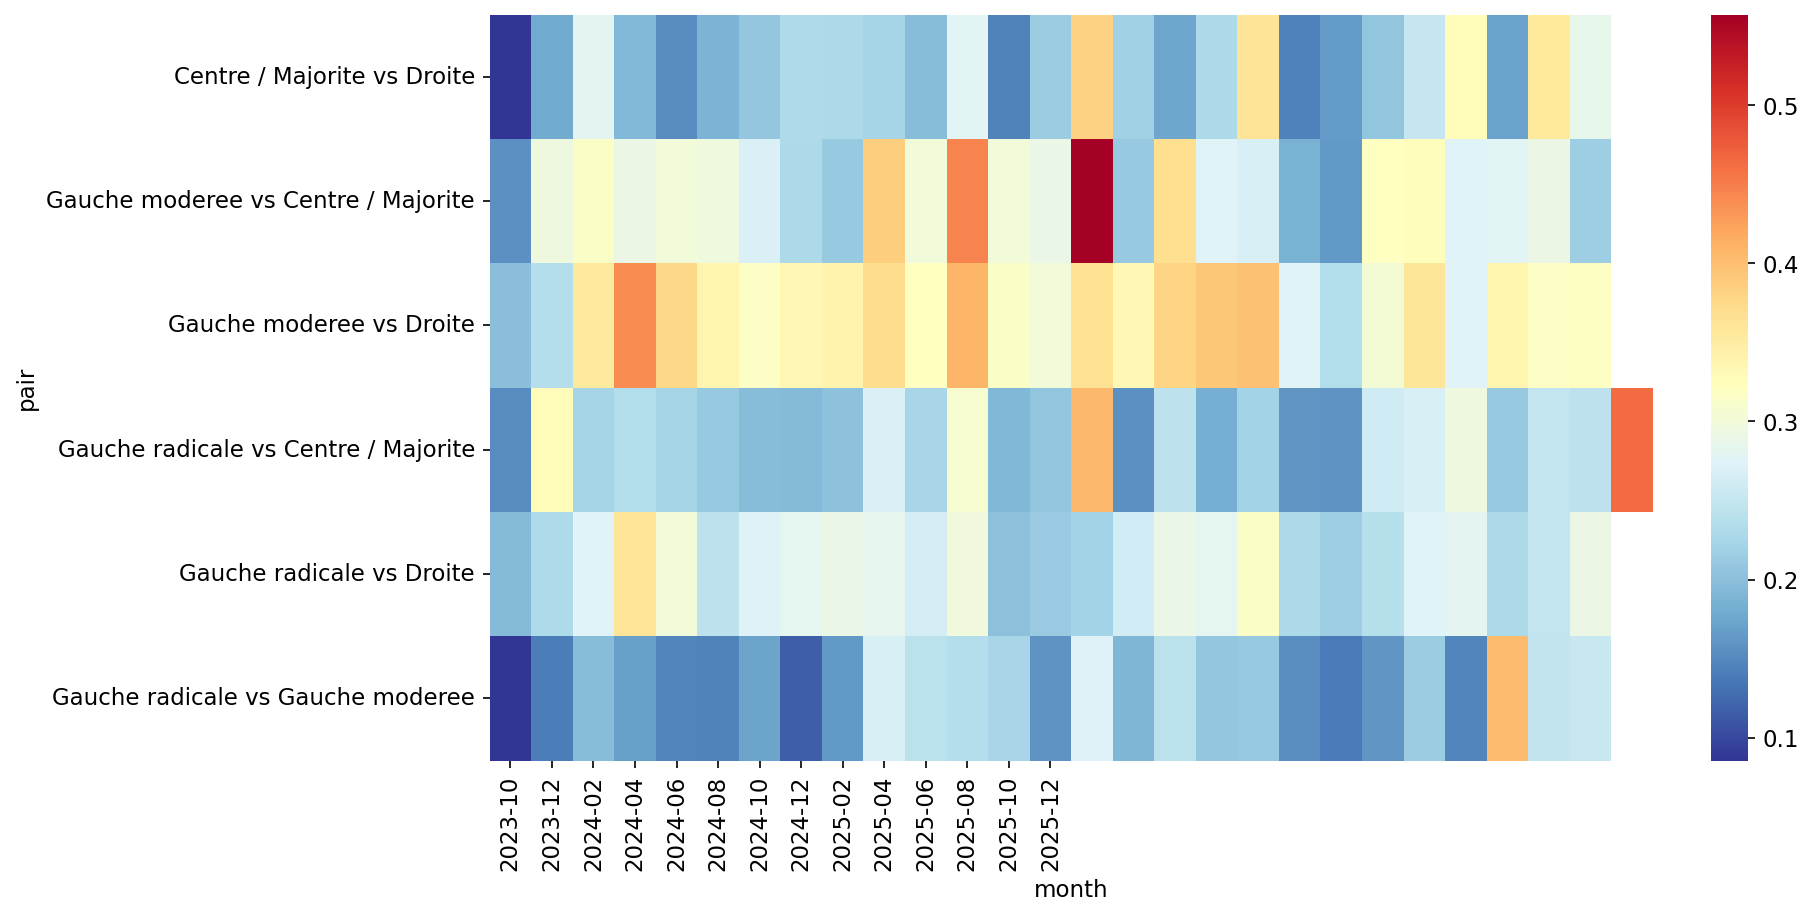

In [5]:
if len(dist_df) > 0:
    piv = dist_df.pivot_table(index='month', columns='pair', values='dist')
    piv = piv.reindex(sorted(piv.index))
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(piv.T, ax=ax, cmap='RdYlBu_r', xticklabels=piv.index[::2])
    save('fig21_cosine_heatmap')

## Figure 3 : Mots distinctifs entre camps (fighting words)

La méthode « fighting words » (Monroe et al., 2008) identifie les termes les plus surreprésentés dans un corpus par rapport à un autre. On compare ici l’ensemble Gauche radicale + Gauche modérée à l’ensemble Droite + Centre / Majorité. Un z-score positif indique un terme typique de la gauche ; un z-score négatif, un terme typique de la droite.

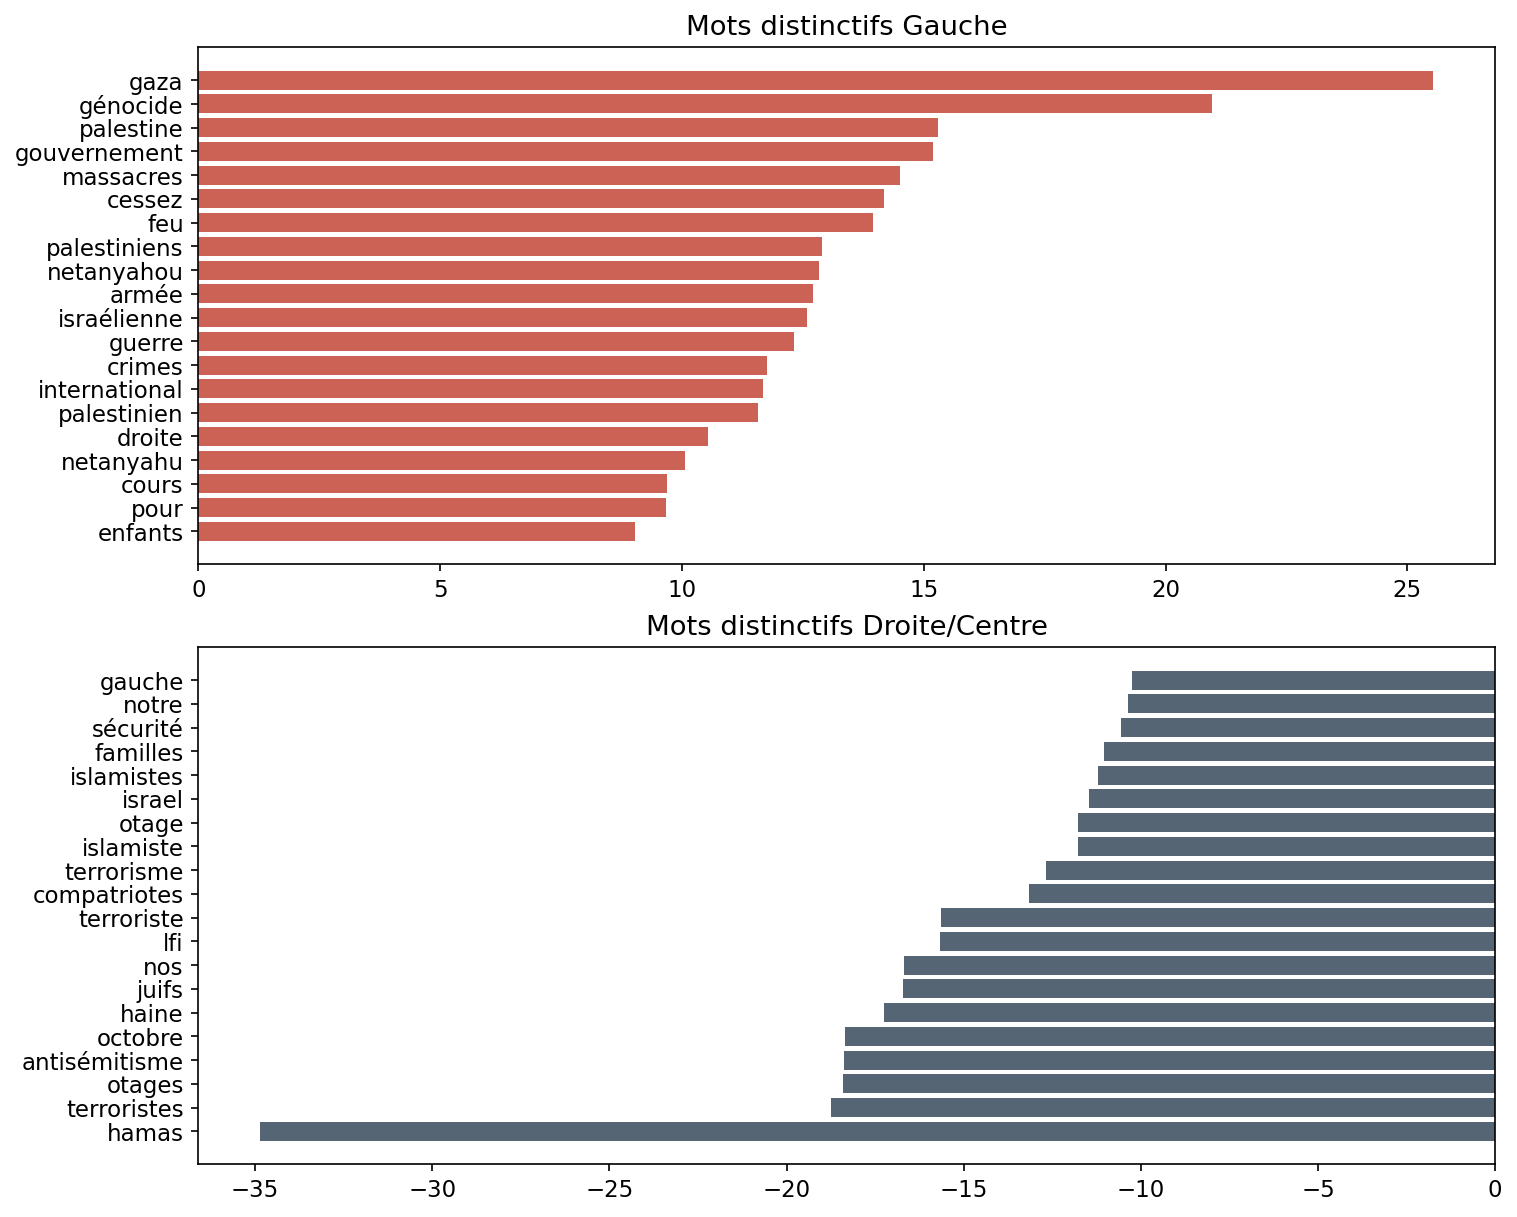

In [6]:
from collections import Counter
import re

def tokenize(text):
    return re.findall(r'[a-zàâäéèêëïîôùûüç]+', str(text).lower())

gauche = df_valid[df_valid['bloc'].isin(['Gauche radicale', 'Gauche moderee'])][text_col]
droite = df_valid[df_valid['bloc'].isin(['Droite', 'Centre / Majorite'])][text_col]

def log_odds(cnt1, cnt2, alpha=0.01):
    n1 = sum(cnt1.values()) + alpha * 2
    n2 = sum(cnt2.values()) + alpha * 2
    all_w = set(cnt1) | set(cnt2)
    out = {}
    for w in all_w:
        c1 = cnt1.get(w, 0) + alpha
        c2 = cnt2.get(w, 0) + alpha
        delta = np.log(c1 / n1) - np.log(c2 / n2)
        var = 1/c1 + 1/c2
        z = delta / np.sqrt(var) if var > 0 else 0
        out[w] = z
    return out

cnt_g = Counter()
for t in gauche.dropna():
    cnt_g.update(tokenize(t))
cnt_d = Counter()
for t in droite.dropna():
    cnt_d.update(tokenize(t))

lod = log_odds(cnt_g, cnt_d)
lod_df = pd.DataFrame([{'word': w, 'z': v} for w, v in lod.items()]).sort_values('z', key=abs, ascending=False)
lod_df.to_csv(RES_DIR / 'fighting_words.csv', index=False)

top_n = 20
top_g = lod_df.nlargest(top_n, 'z')
top_d = lod_df.nsmallest(top_n, 'z')
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].barh(top_g['word'][::-1], top_g['z'][::-1], color='#c0392b', alpha=0.8)
axes[0].set_title('Mots distinctifs Gauche')
axes[1].barh(top_d['word'], top_d['z'], color='#2c3e50', alpha=0.8)
axes[1].set_title('Mots distinctifs Droite/Centre')
save('fig22_fighting_words')

Les termes distinctifs révèlent une opposition entre un vocabulaire humanitaire et juridique (gauche) et un lexique centré sur la sécurité et le terrorisme (droite).

## Figure 4 : Diffusion temporelle du lexique cessez-le-feu

On détecte la présence du lexique lié au cessez-le-feu dans chaque texte par une expression régulière (cessez-le-feu, ceasefire, trêve, cessation des hostilités). Le graphique montre la part mensuelle de textes contenant ce lexique, par bloc politique.

## Figure 3b : Fighting words z-scores temporels (heatmap)

Évolution mensuelle des z-scores des termes les plus distinctifs entre Gauche et Droite. La heatmap révèle les mots dont la surreprésentation varie dans le temps.

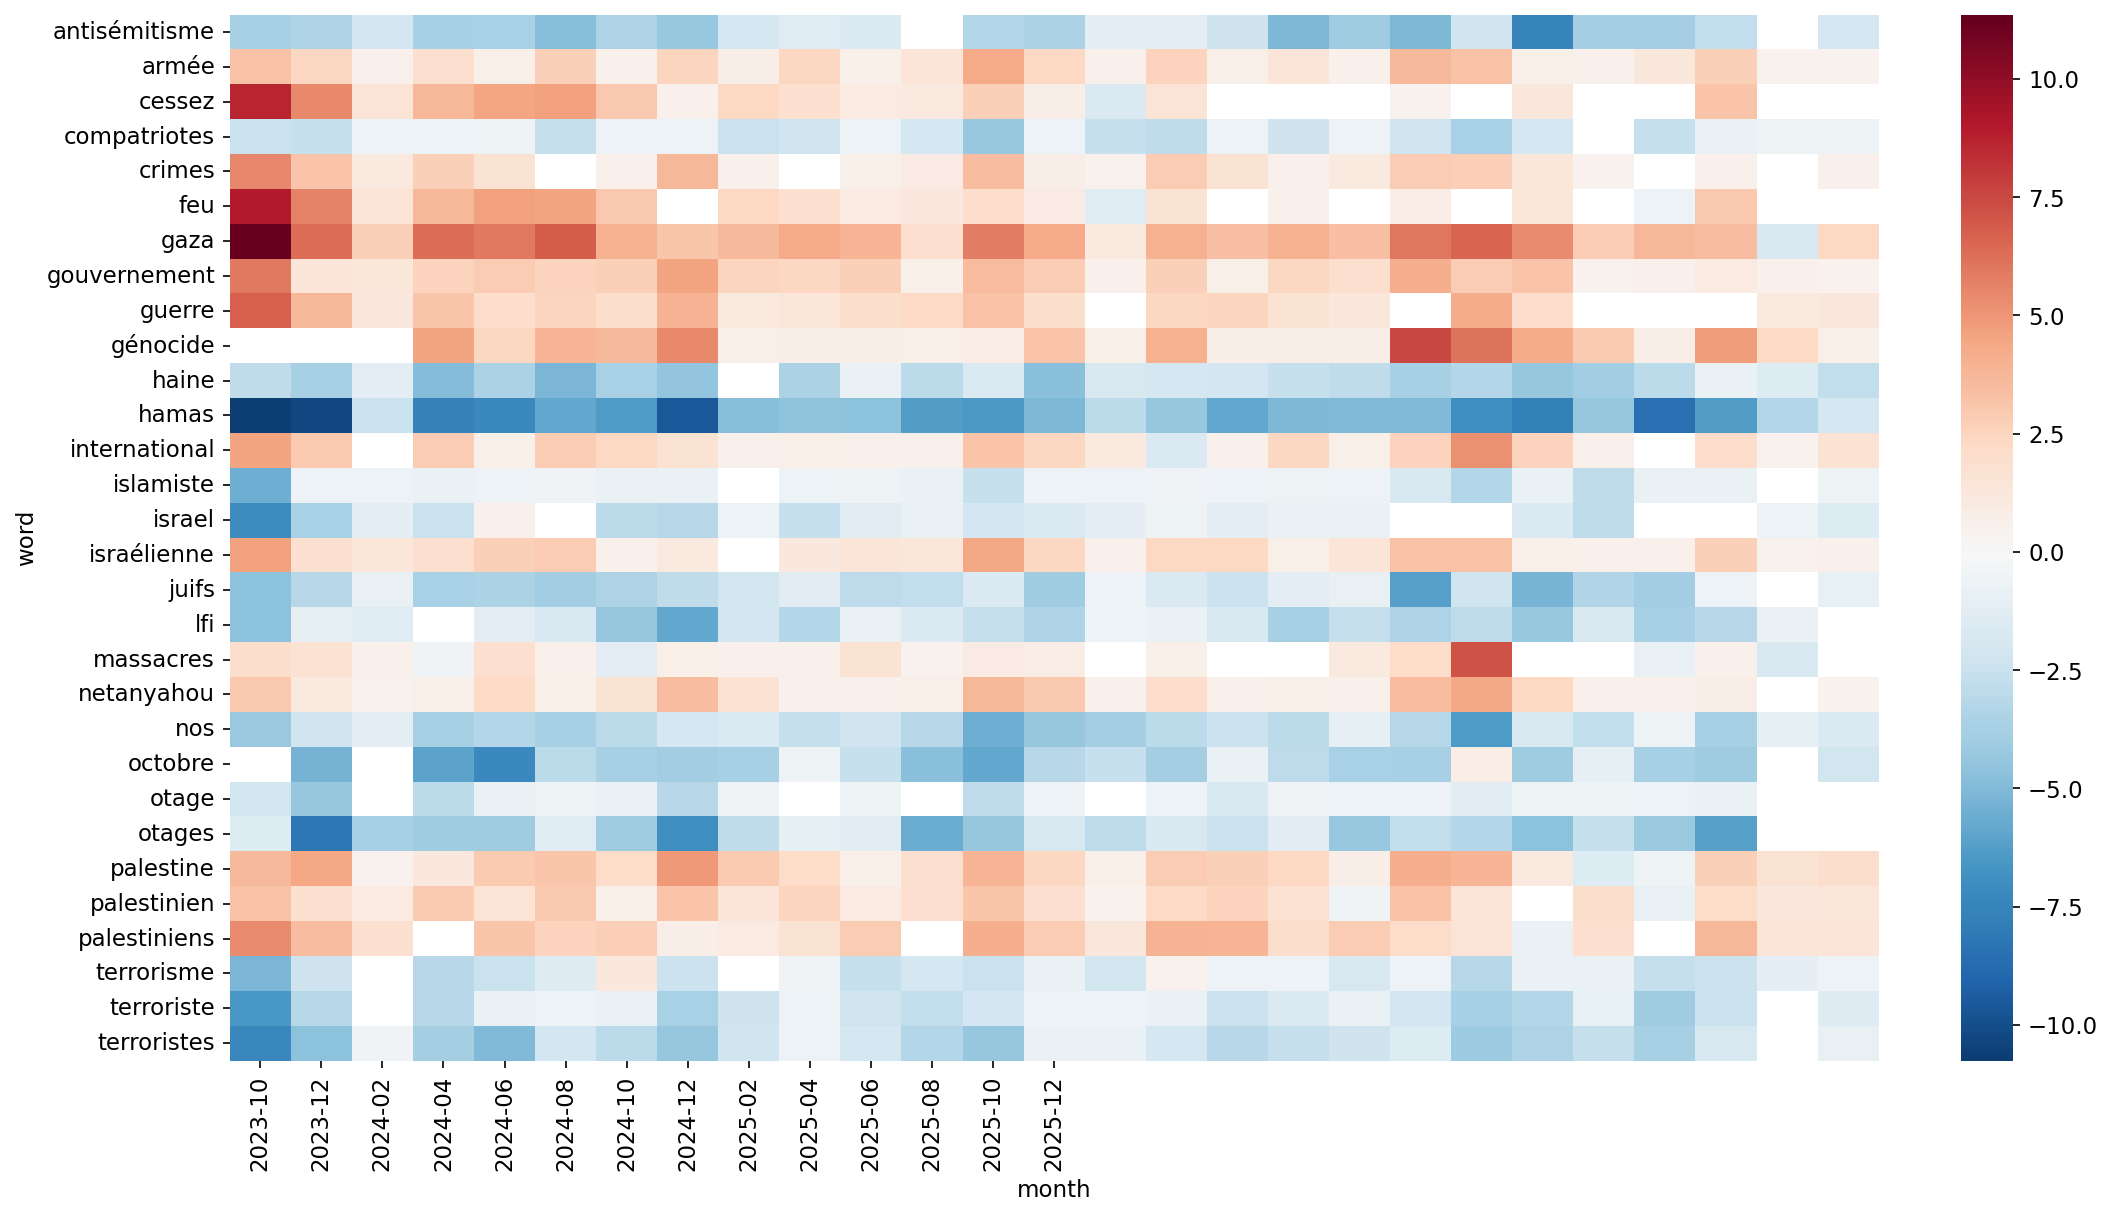

In [7]:
fw_temp = pd.read_csv(RES_DIR / "fighting_words_temporal.csv")
top_words = lod_df.head(30)["word"].tolist() if "lod_df" in dir() else fw_temp.groupby("word")["z"].apply(lambda x: abs(x).max()).nlargest(30).index.tolist()
fw_sub = fw_temp[fw_temp["word"].isin(top_words)]
if len(fw_sub) > 0:
    piv = fw_sub.pivot_table(index="word", columns="month", values="z")
    piv = piv.reindex(columns=sorted(piv.columns))
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(piv, ax=ax, cmap="RdBu_r", center=0, xticklabels=piv.columns[::2])
    save("fig23_fighting_words_temporal")

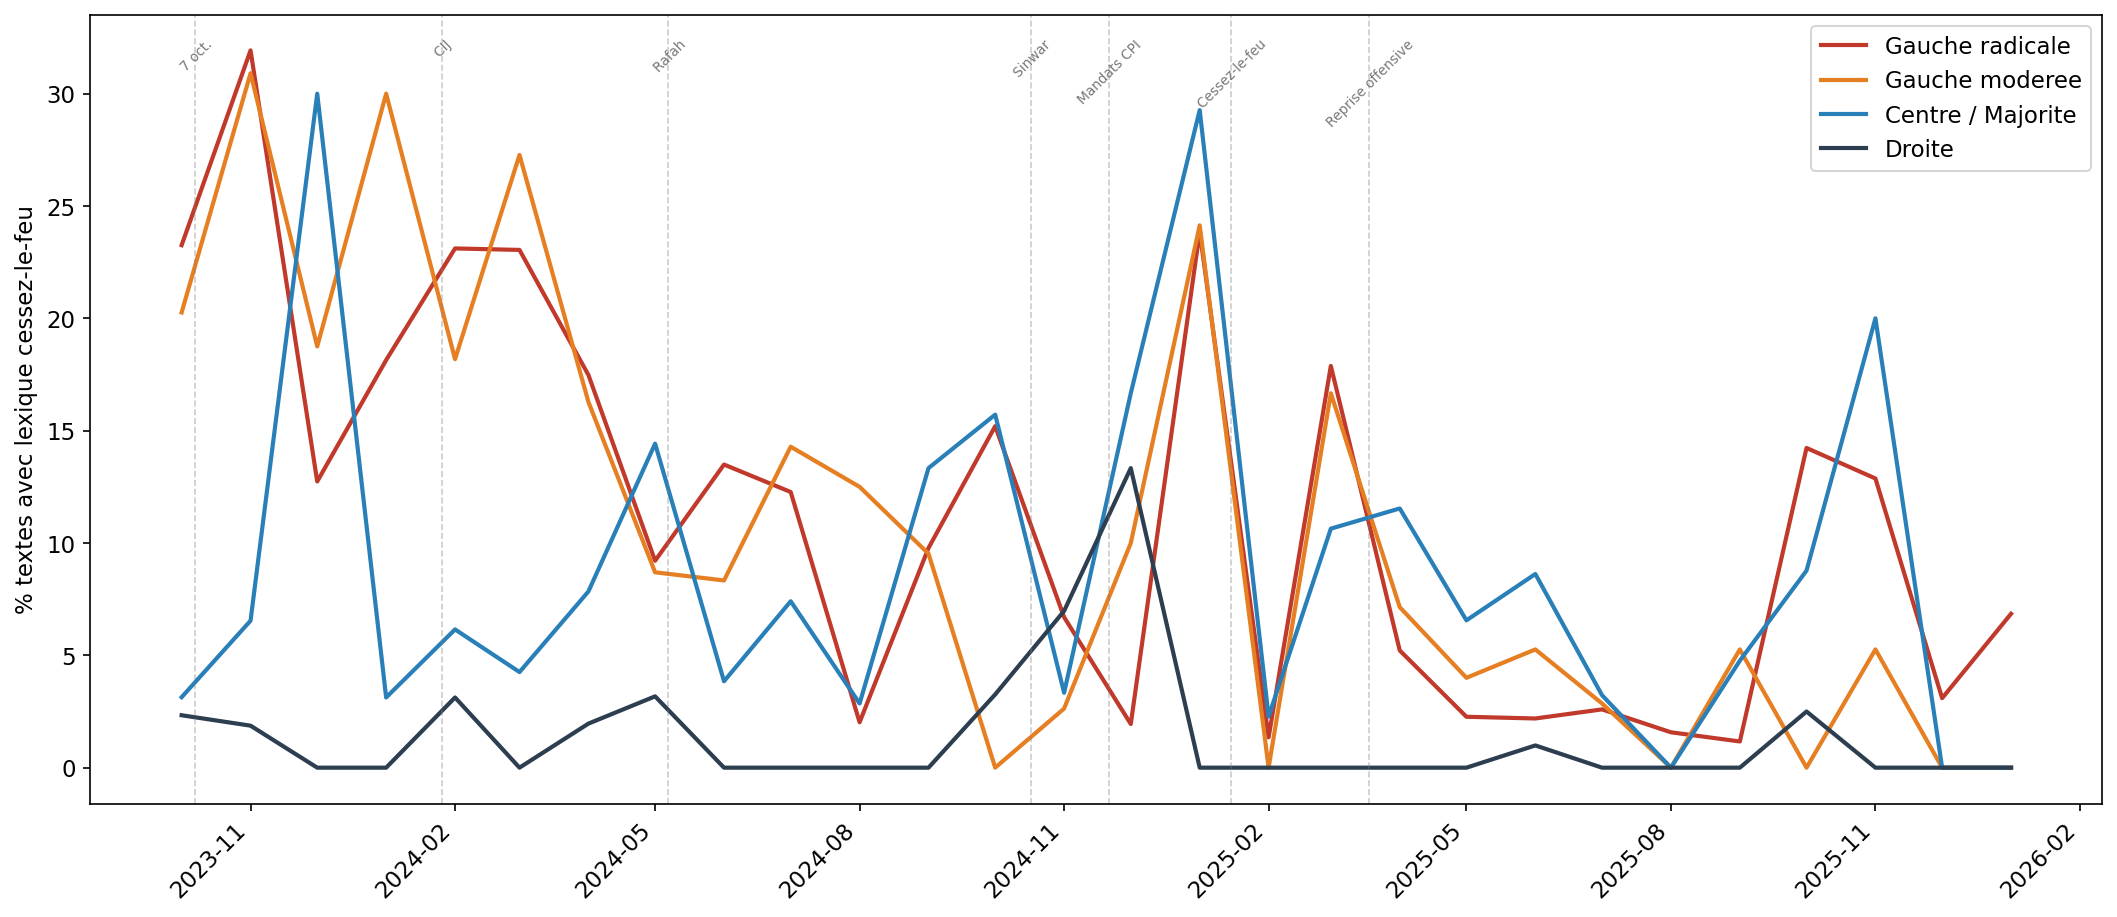

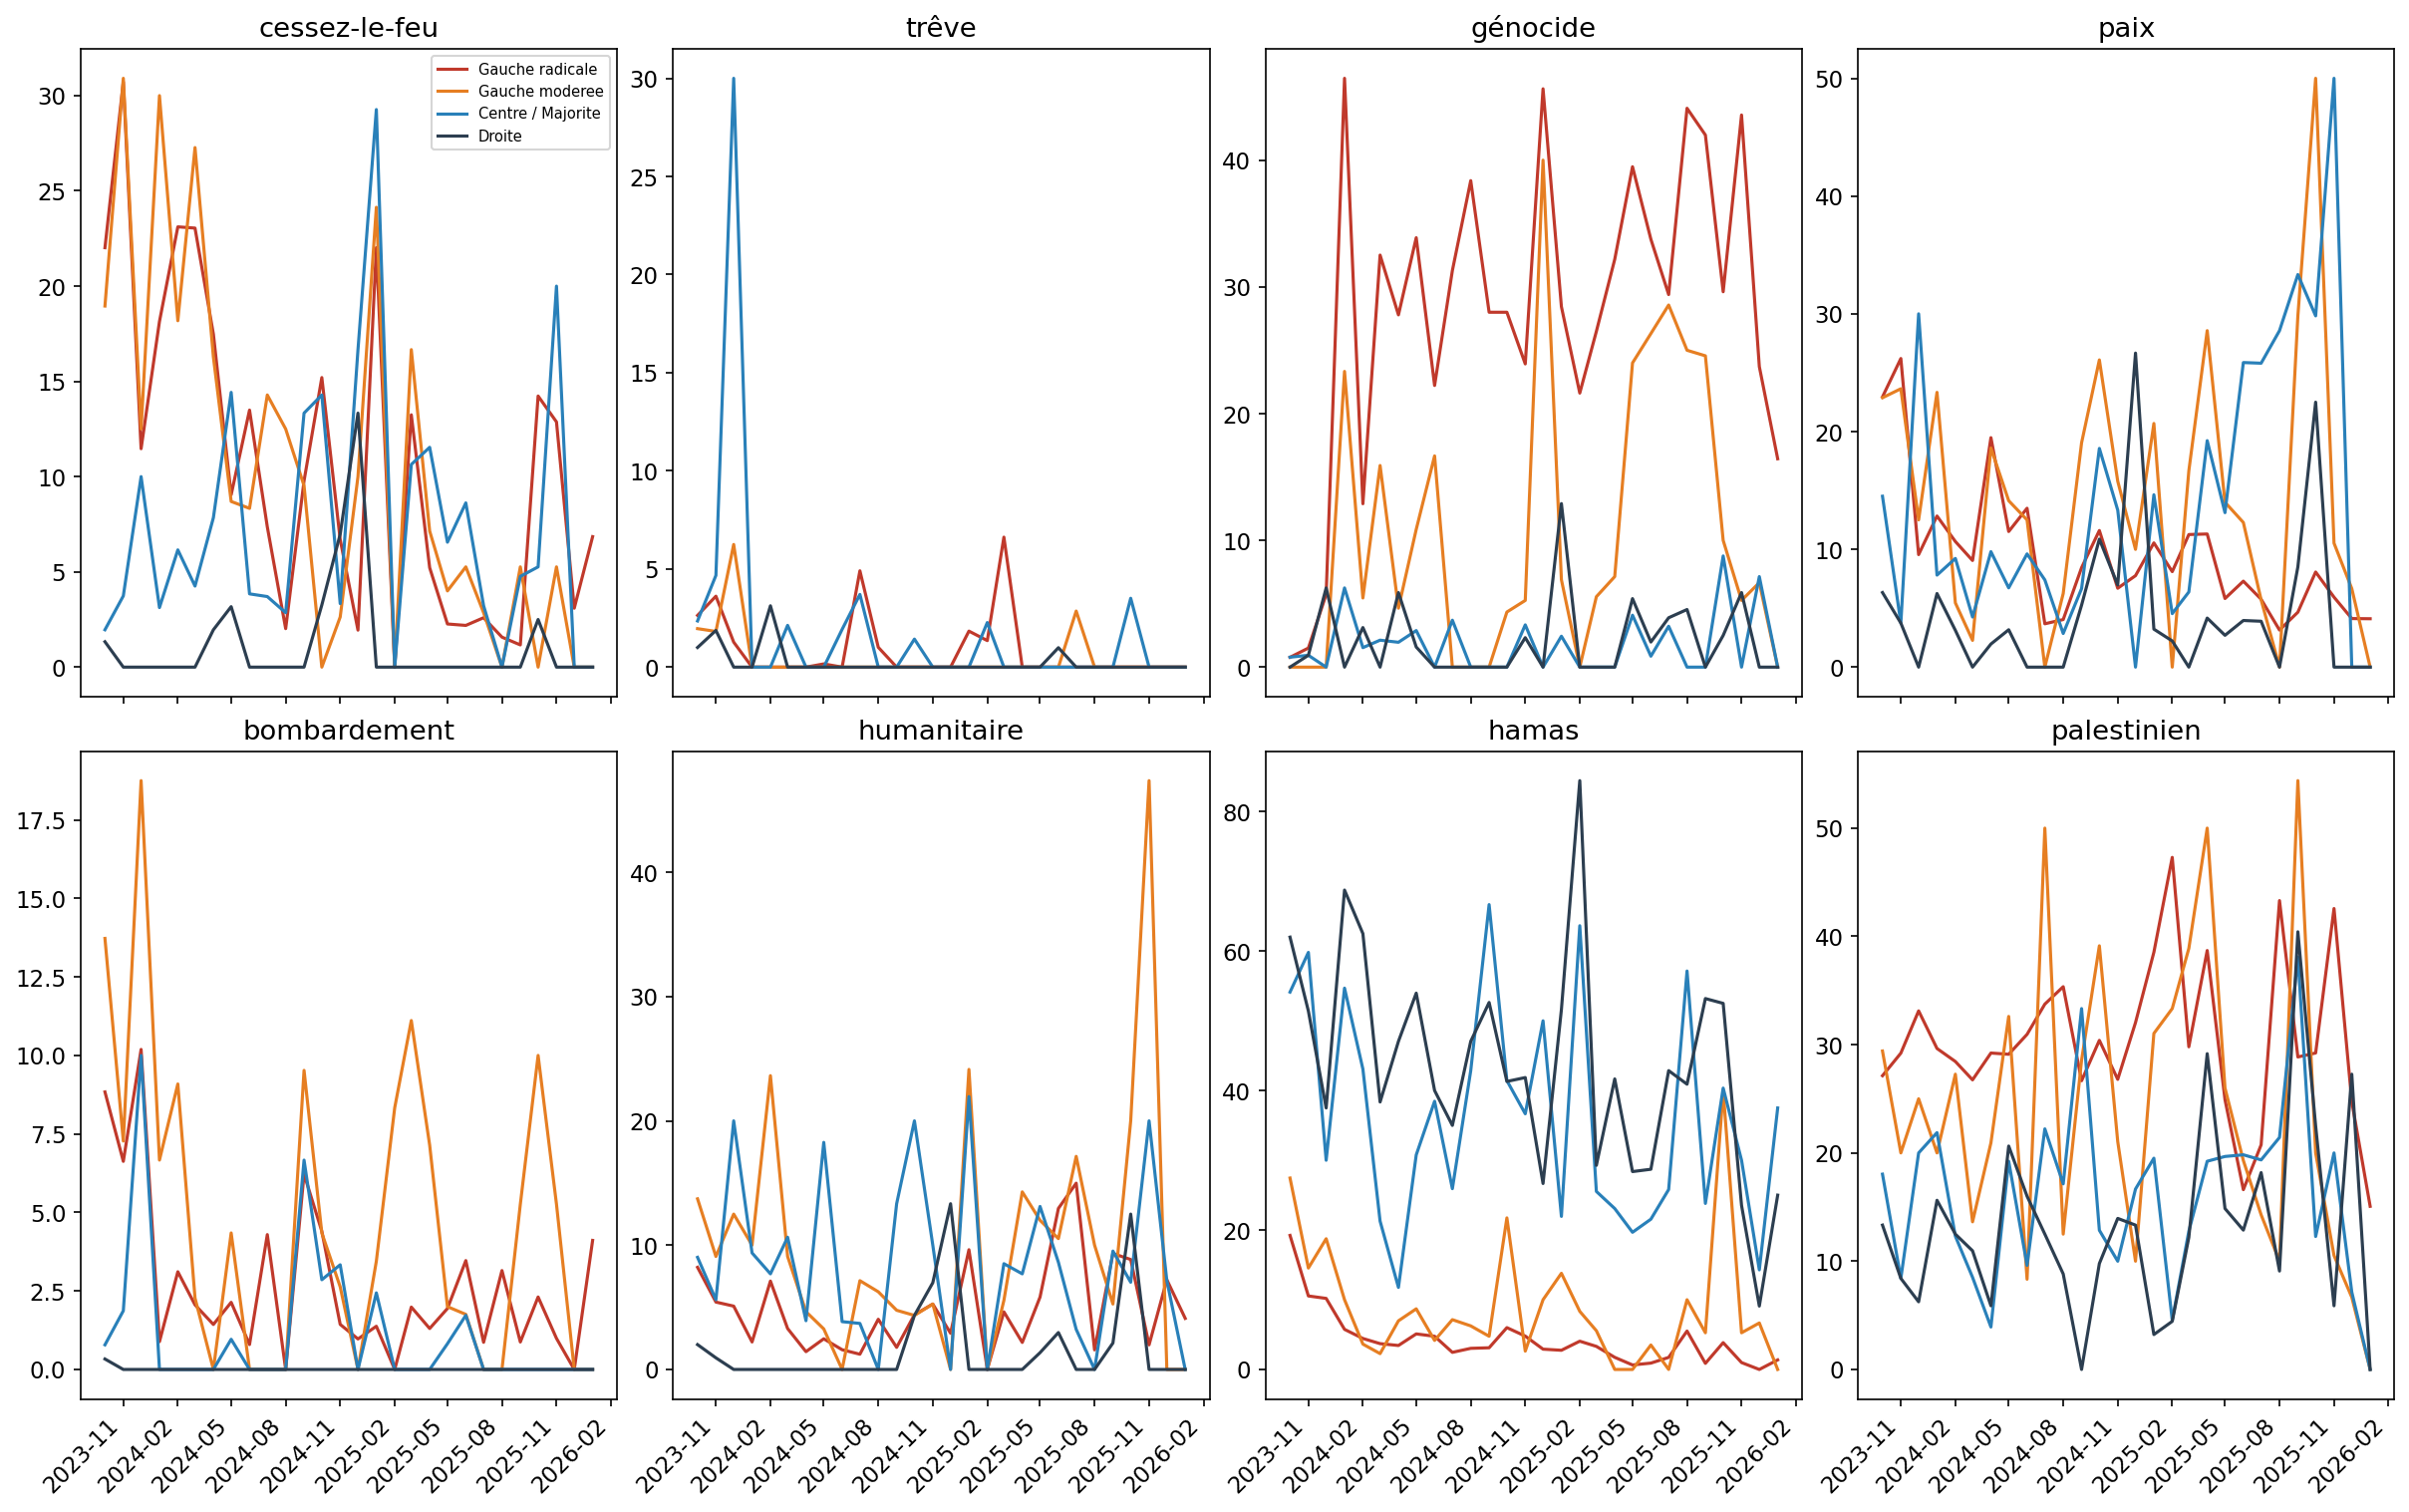

In [8]:
ceasefire_regex = re.compile(r'cessez-le-feu|ceasefire|tr[êe]ve|cessation[ ]+des[ ]+hostilités', re.I)
df_valid['ceasefire_lexical'] = df_valid[text_col].str.contains(ceasefire_regex, na=False)

clf = df_valid.groupby(['month', 'bloc']).agg(pct=('ceasefire_lexical', 'mean'), n=('ceasefire_lexical', 'count')).reset_index()
clf['month_ts'] = pd.to_datetime(clf['month'] + '-01')
clf.to_csv(RES_DIR / 'ceasefire_lexical.csv', index=False)

fig, ax = plt.subplots(figsize=(14, 6))
for bloc in BLOC_ORDER:
    sub = clf[clf['bloc'] == bloc]
    if len(sub) > 0:
        ax.plot(sub['month_ts'], sub['pct'] * 100, label=bloc, color=BLOC_COLORS.get(bloc, '#888'), lw=2)
add_events(ax)
format_dates(ax)
ax.legend(loc='upper right')
ax.set_ylabel('% textes avec lexique cessez-le-feu')
# Fig24 diffusion multi-termes (8 panels)
keywords_multi = [(re.compile(r'cessez-le-feu|ceasefire', re.I), 'cessez-le-feu'), (re.compile(r'tr[êe]ve', re.I), 'trêve'), (re.compile(r'génocide|genocide', re.I), 'génocide'), (re.compile(r'paix', re.I), 'paix'), (re.compile(r'bombardement', re.I), 'bombardement'), (re.compile(r'humanitaire', re.I), 'humanitaire'), (re.compile(r'hamas', re.I), 'hamas'), (re.compile(r'palestinien', re.I), 'palestinien')]
fig, axes = plt.subplots(2, 4, figsize=(16, 10), sharex=True)
for ix, (regex, label) in enumerate(keywords_multi):
    ax = axes.flat[ix]
    df_valid['_kw'] = df_valid[text_col].str.contains(regex, na=False)
    agg = df_valid.groupby(['month', 'bloc'])['_kw'].mean().reset_index()
    agg['month_ts'] = pd.to_datetime(agg['month'] + '-01')
    for bloc in BLOC_ORDER:
        sub = agg[agg['bloc'] == bloc]
        if len(sub) > 0:
            ax.plot(sub['month_ts'], sub['_kw'] * 100, color=BLOC_COLORS.get(bloc, '#888'), lw=1.5)
    ax.set_title(label)
    format_dates(ax)
axes[0, 0].legend(BLOC_ORDER, loc='upper right', fontsize=7)
save('fig24_diffusion_multi_termes')

La diffusion du lexique cessez-le-feu progresse de la Gauche radicale vers le Centre avec un décalage temporel d’environ quatorze mois. La Droite reste à l’écart de cette adoption lexicale tout au long de la période.

## Figure 5 : Indice agrégé de polarisation lexicale

Distance cosinus moyenne entre toutes les paires de blocs, par mois. Une valeur élevée indique une divergence globale des vocabulaires.

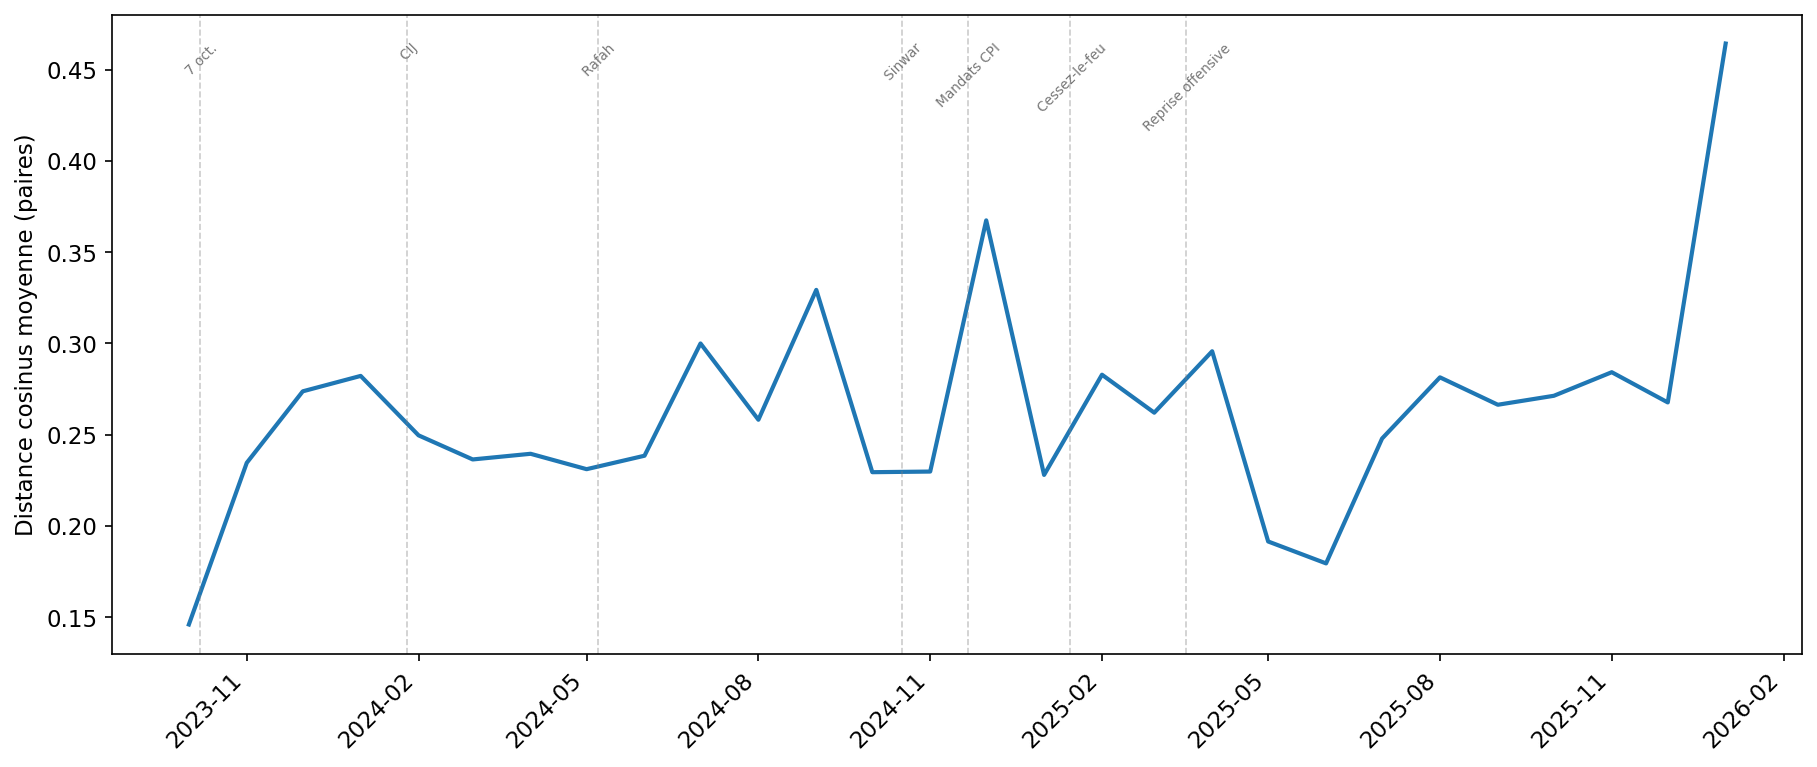

In [9]:
if len(dist_df) > 0:
    pol_idx = dist_df.groupby('month')['dist'].mean().reset_index()
    pol_idx['month_ts'] = pd.to_datetime(pol_idx['month'] + '-01')
    pol_idx.to_csv(RES_DIR / 'polarisation_index.csv', index=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(pol_idx['month_ts'], pol_idx['dist'], lw=2)
    add_events(ax)
    format_dates(ax)
    ax.set_ylabel('Distance cosinus moyenne (paires)')
    save('fig26_polarisation_index')

L’indice de polarisation lexicale suit une trajectoire ascendante en fin de période, cohérente avec une divergence accrue des positions discursives entre blocs.

## Figure 5b : Lag d'adoption du lexique cessez-le-feu

Mois où chaque bloc dépasse pour la première fois 10 % de textes contenant le lexique cessez-le-feu, illustrant le décalage temporel de diffusion entre blocs.

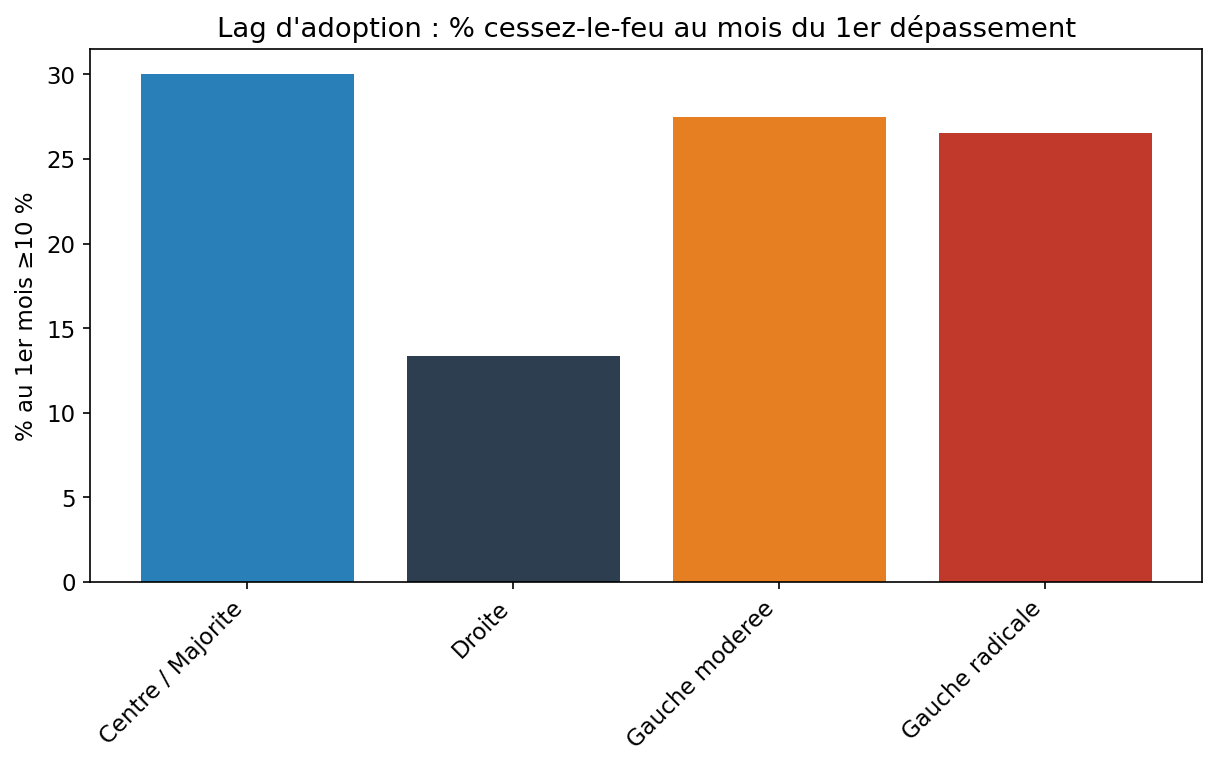

In [10]:
lag = pd.read_csv(RES_DIR / "lag_adoption.csv")
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(lag)), lag["pct"], color=[BLOC_COLORS.get(b, "#888") for b in lag["bloc"]])
ax.set_xticks(range(len(lag)))
ax.set_xticklabels(lag["bloc"], rotation=45, ha="right")
ax.set_ylabel("% au 1er mois ≥10 %")
ax.set_title("Lag d'adoption : % cessez-le-feu au mois du 1er dépassement")
save("fig25_lag_adoption")

## Polarisation entropique (Bao & Gill 2024)

La polarisation entropique Ec mesure la bimodalité de la distribution des positions, indépendamment des moyennes. Ec = 0 (consensus), Ec = 1 (polarisation maximale).

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_13992\4273018128.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


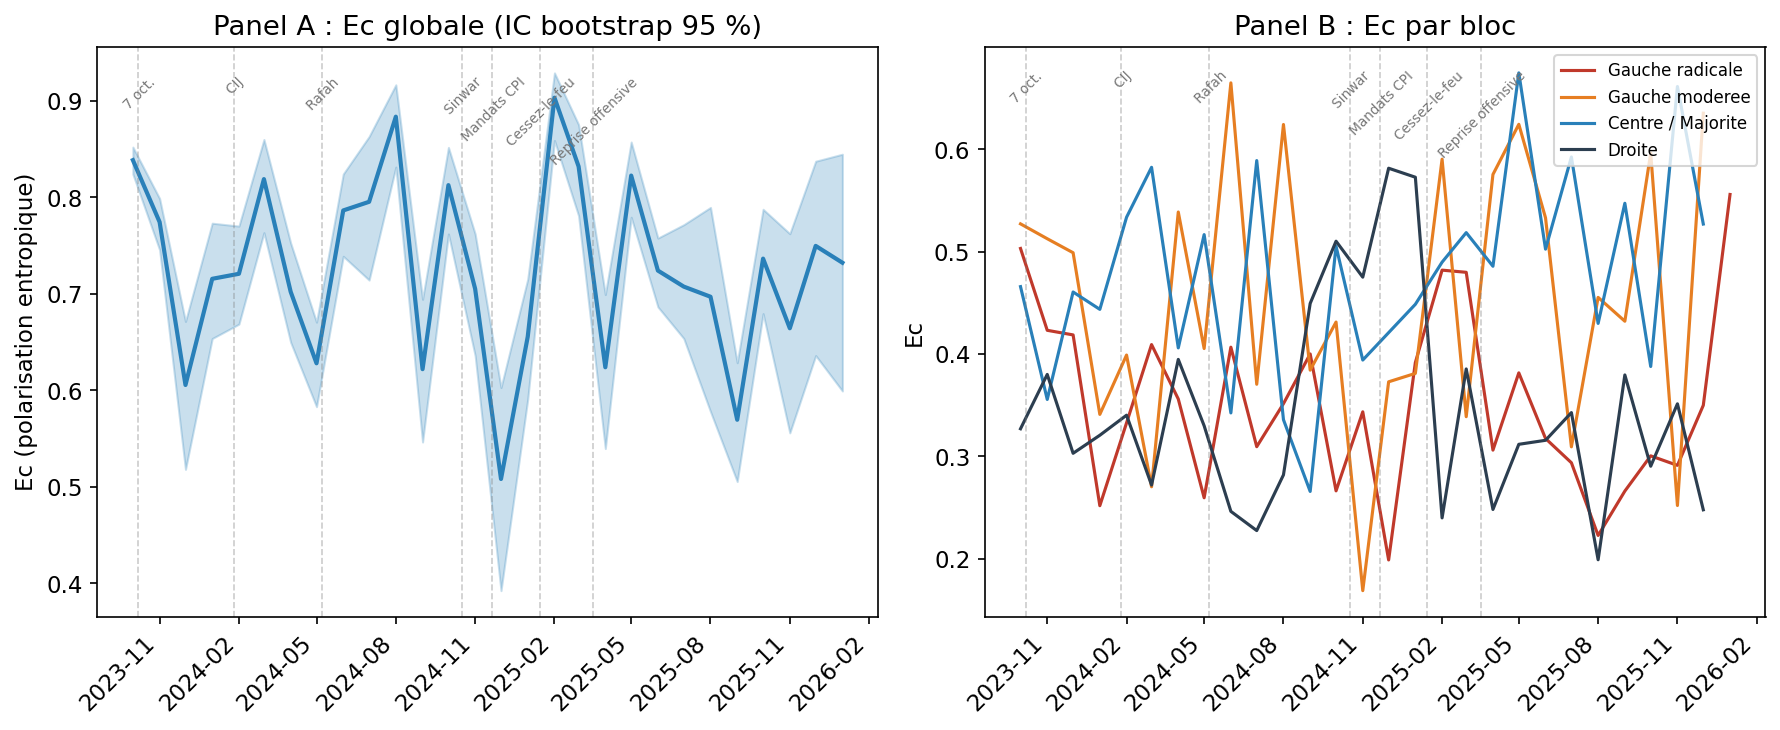

In [11]:
from vendeville import entropic_polarization_bao_gill

ec_global, ec_by_bloc = [], []
for m, sub in df_valid.groupby('month'):
    vals = sub['stance_v3'].dropna()
    if len(vals) >= 10:
        ec_global.append({'month': m, 'Ec': entropic_polarization_bao_gill(vals), 'n': len(vals)})
    for bloc in BLOC_ORDER:
        bvals = sub[sub['bloc'] == bloc]['stance_v3'].dropna()
        if len(bvals) >= 10:
            ec_by_bloc.append({'month': m, 'bloc': bloc, 'Ec': entropic_polarization_bao_gill(bvals), 'n': len(bvals)})

ec_df = pd.DataFrame(ec_global)
ec_bloc_df = pd.DataFrame(ec_by_bloc)

# Bootstrap IC 95% pour Ec globale
def ec_bootstrap(values, n_boot=500):
    ecs = [entropic_polarization_bao_gill(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    return np.percentile(ecs, 2.5), np.percentile(ecs, 97.5)

ec_df['month_ts'] = pd.to_datetime(ec_df['month'] + '-01')
ec_df['ec_lo'] = np.nan
ec_df['ec_hi'] = np.nan
for i, row in ec_df.iterrows():
    sub = df_valid[df_valid['month'] == row['month']]['stance_v3'].dropna()
    if len(sub) >= 20:
        ec_df.loc[i, 'ec_lo'], ec_df.loc[i, 'ec_hi'] = ec_bootstrap(sub.values)

if len(ec_bloc_df) > 0:
    ec_bloc_df['month_ts'] = pd.to_datetime(ec_bloc_df['month'] + '-01')
ec_df.to_csv(RES_DIR / 'entropic_polarization_temporal.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.plot(ec_df['month_ts'], ec_df['Ec'], lw=2, color='#2980b9')
ax.fill_between(ec_df['month_ts'], ec_df['ec_lo'], ec_df['ec_hi'], alpha=0.25, color='#2980b9')
add_events(ax)
ax.set_ylabel('Ec (polarisation entropique)')
ax.set_title('Panel A : Ec globale (IC bootstrap 95 %)')
format_dates(ax)

ax = axes[1]
for bloc in BLOC_ORDER:
    sub = ec_bloc_df[ec_bloc_df['bloc'] == bloc]
    if len(sub) > 0:
        ax.plot(sub['month_ts'], sub['Ec'], label=bloc, color=BLOC_COLORS.get(bloc, '#888'), lw=1.5)
add_events(ax)
ax.set_ylabel('Ec')
ax.set_title('Panel B : Ec par bloc')
ax.legend(loc='upper right', fontsize=8)
format_dates(ax)
plt.tight_layout()
save('fig52_entropic_polarization_temporal')

## Distance de Wasserstein

La distance de Wasserstein normalisée (WD / 4.0) mesure la convergence des distributions de stance entre blocs. WD élevée = distributions éloignées (polarisation) ; WD faible = distributions proches (convergence).

In [12]:
from vendeville import wd_inter_blocs, wd_drift_intra_bloc

pairs = [(b1, b2) for i, b1 in enumerate(BLOC_ORDER) for b2 in BLOC_ORDER[i+1:]]
wd_inter = wd_inter_blocs(df_valid, pairs)
wd_drift_list = []
for bloc in BLOC_ORDER:
    d = wd_drift_intra_bloc(df_valid, bloc)
    if len(d) > 0:
        wd_drift_list.append(d)
wd_drift = pd.concat(wd_drift_list, ignore_index=True) if wd_drift_list else pd.DataFrame()

wd_inter.to_csv(RES_DIR / 'wasserstein_inter_blocs.csv', index=False)
if len(wd_drift) > 0:
    wd_drift.to_csv(RES_DIR / 'wasserstein_drift.csv', index=False)

wd_mean = wd_inter.groupby('month')['wd_norm'].mean().reset_index()
wd_mean['month_ts'] = pd.to_datetime(wd_mean['month'] + '-01')
pol_path = RES_DIR / 'polarisation_index.csv'
if pol_path.exists():
    pol_idx = pd.read_csv(pol_path)
    pol_idx = pol_idx.merge(wd_mean[['month', 'wd_norm']].rename(columns={'wd_norm': 'wd_mean'}), on='month', how='left')
    pol_idx.to_csv(pol_path, index=False)

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_13992\4254378103.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


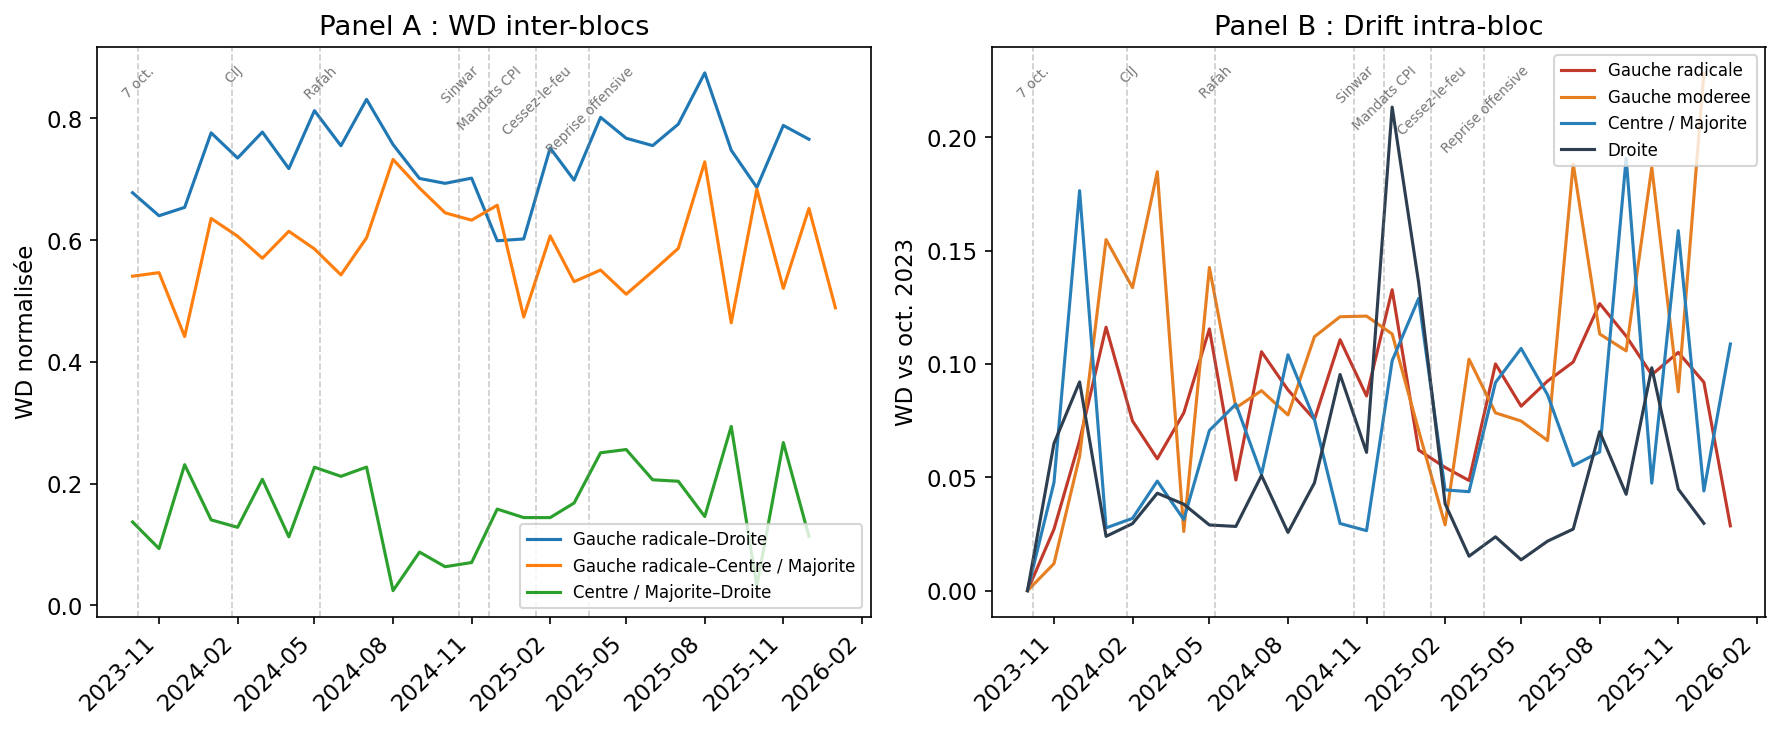

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
key_pairs = ['Gauche radicale vs Droite', 'Gauche radicale vs Centre / Majorite', 'Centre / Majorite vs Droite']
for pair in key_pairs:
    sub = wd_inter[wd_inter['pair'] == pair]
    if len(sub) > 0:
        sub = sub.copy()
        sub['month_ts'] = pd.to_datetime(sub['month'] + '-01')
        ax.plot(sub['month_ts'], sub['wd_norm'], label=pair.replace(' vs ', '–'), lw=1.5)
add_events(ax)
ax.set_ylabel('WD normalisée')
ax.set_title('Panel A : WD inter-blocs')
ax.legend(fontsize=8)
format_dates(ax)

ax = axes[1]
if len(wd_drift) > 0:
    wd_drift['month_ts'] = pd.to_datetime(wd_drift['month'] + '-01')
    for bloc in BLOC_ORDER:
        sub = wd_drift[wd_drift['bloc'] == bloc]
        if len(sub) > 0:
            ax.plot(sub['month_ts'], sub['wd_norm'], label=bloc, color=BLOC_COLORS.get(bloc, '#888'), lw=1.5)
add_events(ax)
ax.set_ylabel('WD vs oct. 2023')
ax.set_title('Panel B : Drift intra-bloc')
ax.legend(loc='upper right', fontsize=8)
format_dates(ax)
plt.tight_layout()
save('fig53_wasserstein_convergence')

## Effective Dimensionality

L’Effective Dimensionality (ED) mesure la complexité de l’espace politique : combien de dimensions sont nécessaires pour capturer la variance des positions. ED = 1 si une seule dimension suffit ; ED élevé si plusieurs dimensions coexistent.

In [14]:
from vendeville import effective_dimensionality
from sklearn.preprocessing import StandardScaler

deputy_month = df_valid.groupby(['author', 'month']).agg(
    stance_mean=('stance_v3', 'mean'),
    clf_pct=('ceasefire_lexical', 'mean'),
    engagement_mean=('engagement', 'mean')
).reset_index()
deputy_month = deputy_month.dropna(subset=['stance_mean', 'clf_pct'])

ed_list = []
for m in sorted(df_valid['month'].unique()):
    sub = deputy_month[deputy_month['month'] == m]
    if len(sub) >= 20:
        feat_cols = [c for c in ['stance_mean', 'clf_pct', 'engagement_mean'] if c in sub.columns and sub[c].notna().sum() >= len(sub)//2]
        if len(feat_cols) >= 2:
            X = sub[feat_cols].fillna(0).values
            X_std = StandardScaler().fit_transform(X)
            ed = effective_dimensionality(X_std)
            ed_list.append({'month': m, 'ED': ed, 'n': len(sub), 'n_feat': len(feat_cols)})
ed_df = pd.DataFrame(ed_list)
ed_df['month_ts'] = pd.to_datetime(ed_df['month'] + '-01')
ed_df.to_csv(RES_DIR / 'effective_dimensionality_temporal.csv', index=False)

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_13992\1120666433.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


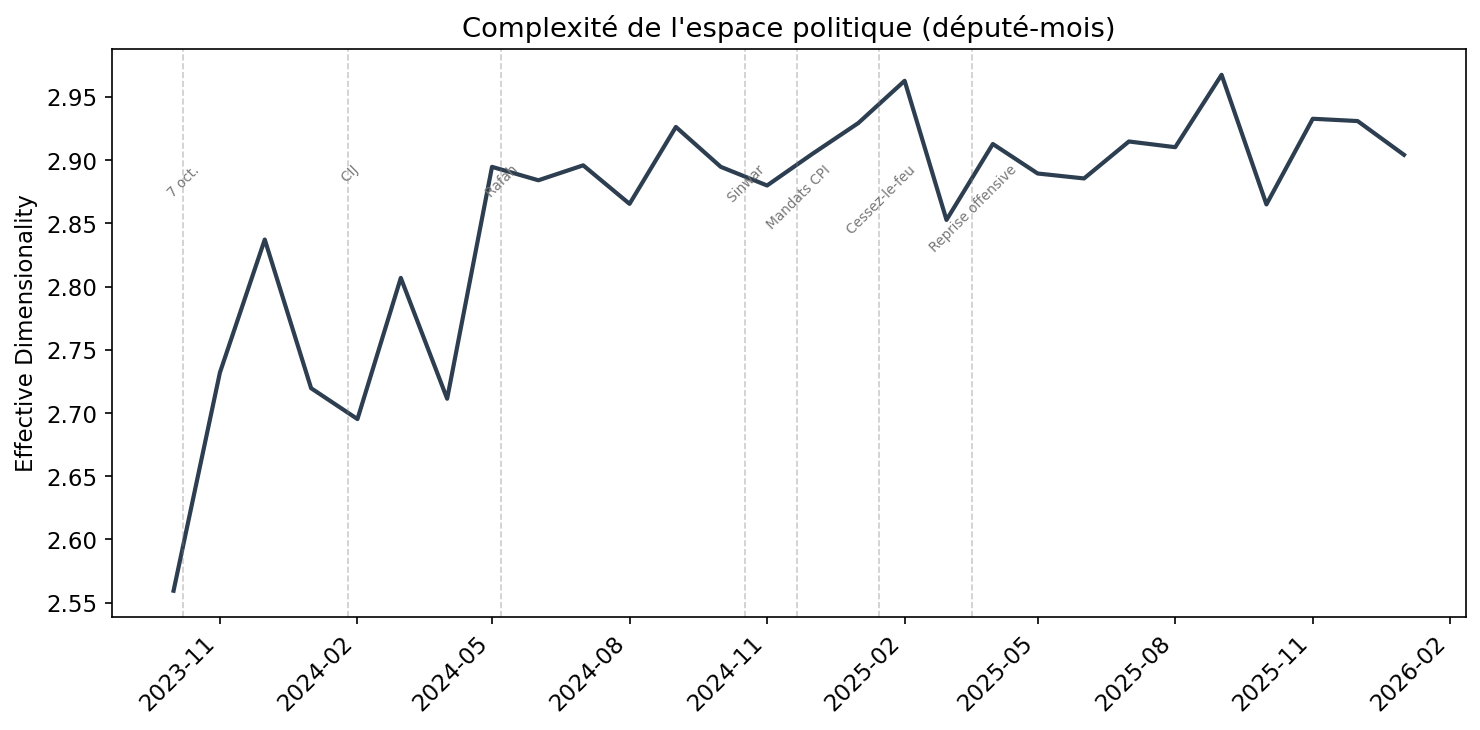

In [15]:
if len(ed_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ed_df['month_ts'], ed_df['ED'], lw=2, color='#2c3e50')
    add_events(ax)
    ax.set_ylabel('Effective Dimensionality')
    ax.set_title('Complexité de l\'espace politique (député-mois)')
    format_dates(ax)
    plt.tight_layout()
    save('fig54_effective_dimensionality')

## Polarisation affective (VAD)

Les registres émotionnels (Valence, Arousal, Dominance, lexique NRC-VAD) sont indépendants du stance idéologique. Si le vocabulaire converge mais les émotions restent séparées, la convergence est de surface.

In [16]:
from vad_lexicon import load_vad_lexicon, score_text_vad

lex = load_vad_lexicon()
df_valid['_vad'] = df_valid[text_col].apply(score_text_vad)
df_valid['valence'] = df_valid['_vad'].apply(lambda x: x[0] if isinstance(x, tuple) else float('nan'))
df_valid['arousal'] = df_valid['_vad'].apply(lambda x: x[1] if isinstance(x, tuple) else float('nan'))
df_valid['dominance'] = df_valid['_vad'].apply(lambda x: x[2] if isinstance(x, tuple) else float('nan'))

vad_bloc = df_valid.groupby(['month', 'bloc']).agg(
    valence=('valence', 'mean'), arousal=('arousal', 'mean'), dominance=('dominance', 'mean'),
    n=('valence', 'count')
).reset_index()
vad_bloc = vad_bloc[vad_bloc['n'] >= 5]
vad_bloc['month_ts'] = pd.to_datetime(vad_bloc['month'] + '-01')
vad_bloc.to_csv(RES_DIR / 'affective_vad_by_bloc_month.csv', index=False)

from scipy.spatial.distance import euclidean
gap_list = []
for m in vad_bloc['month'].unique():
    sub = vad_bloc[vad_bloc['month'] == m]
    blocs = sub['bloc'].tolist()
    if len(blocs) >= 2:
        for i in range(len(blocs)):
            for j in range(i + 1, len(blocs)):
                r1, r2 = sub.iloc[i], sub.iloc[j]
                v1 = (r1['valence'], r1['arousal'], r1['dominance'])
                v2 = (r2['valence'], r2['arousal'], r2['dominance'])
                gap_list.append({'month': m, 'pair': f"{r1['bloc']} vs {r2['bloc']}", 'gap_vad': euclidean(v1, v2)})
gap_df = pd.DataFrame(gap_list)
if len(gap_df) > 0:
    gap_agg = gap_df.groupby('month')['gap_vad'].mean().reset_index()
    gap_agg['month_ts'] = pd.to_datetime(gap_agg['month'] + '-01')
    gap_agg.to_csv(RES_DIR / 'affective_polarization_temporal.csv', index=False)

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_13992\3751312251.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


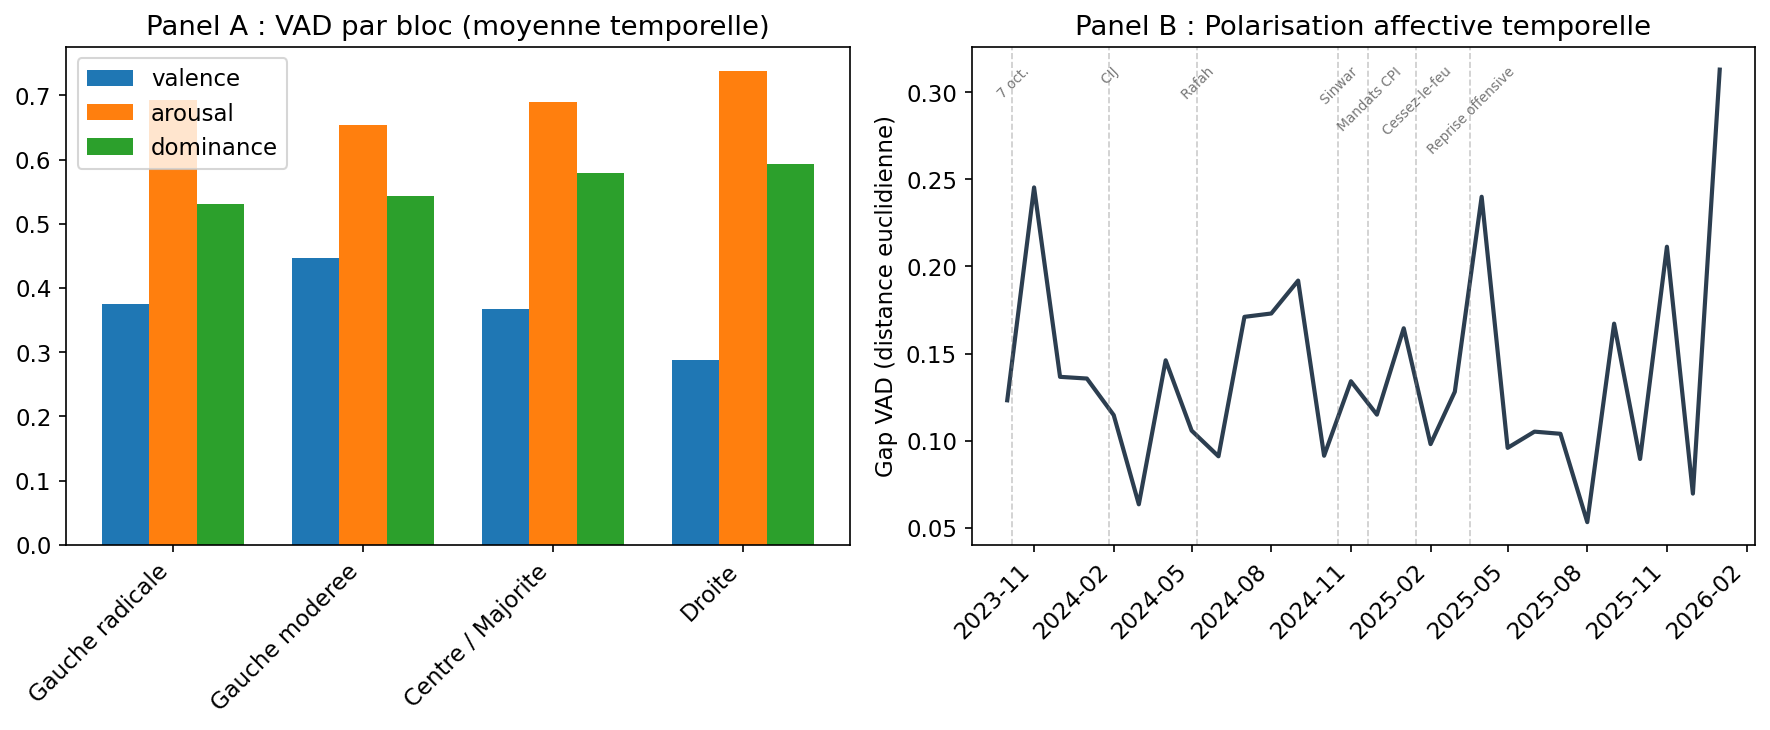

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_13992\3751312251.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


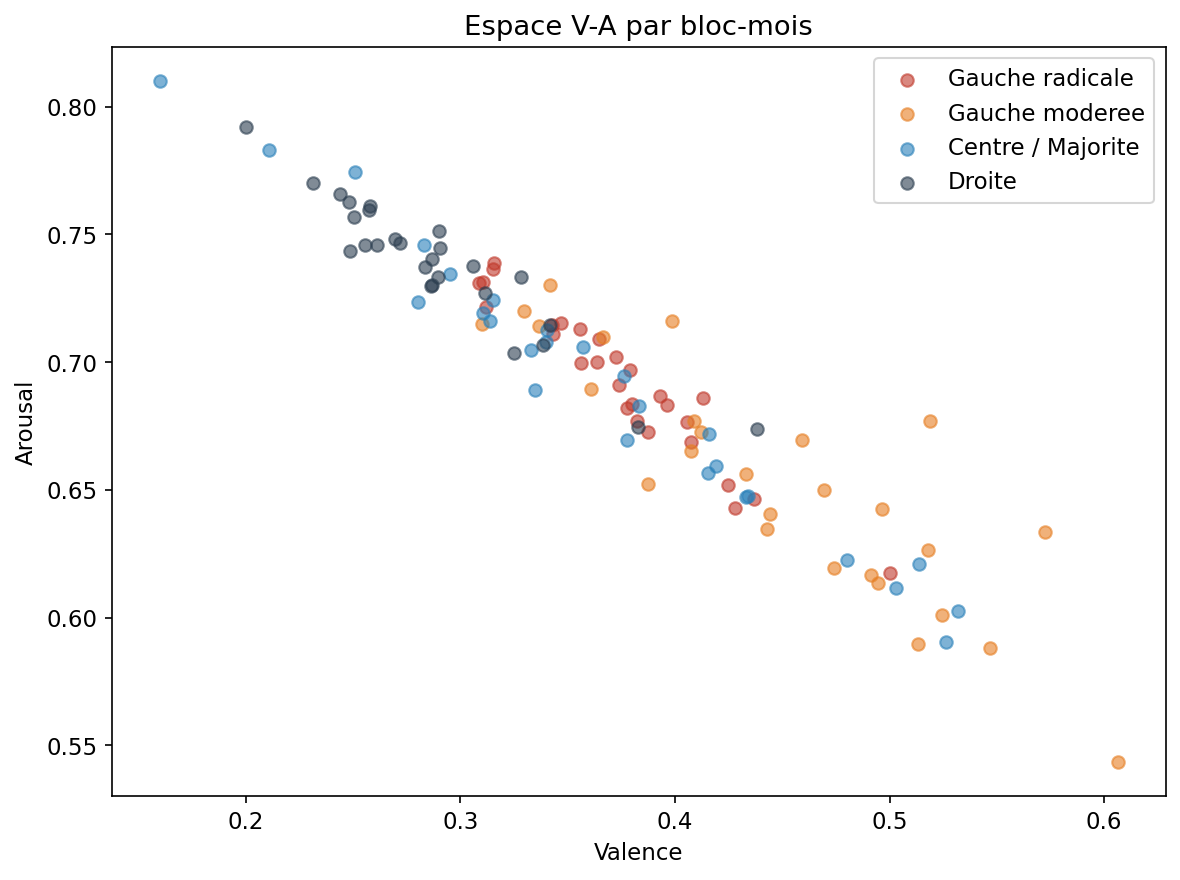

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.set_title('Panel A : VAD par bloc (moyenne temporelle)')
vad_mean = vad_bloc.groupby('bloc')[['valence', 'arousal', 'dominance']].mean()
x = range(len(BLOC_ORDER))
w = 0.25
for i, dim in enumerate(['valence', 'arousal', 'dominance']):
    vals = [vad_mean.loc[b, dim] if b in vad_mean.index else 0 for b in BLOC_ORDER]
    ax.bar([xi + i*w for xi in x], vals, width=w, label=dim)
ax.set_xticks([xi + w for xi in x])
ax.set_xticklabels(BLOC_ORDER, rotation=45, ha='right')
ax.legend()

ax = axes[1]
if len(gap_df) > 0:
    gap_agg = gap_df.groupby('month')['gap_vad'].mean().reset_index()
    gap_agg['month_ts'] = pd.to_datetime(gap_agg['month'] + '-01')
    ax.plot(gap_agg['month_ts'], gap_agg['gap_vad'], lw=2, color='#2c3e50')
add_events(ax)
ax.set_ylabel('Gap VAD (distance euclidienne)')
ax.set_title('Panel B : Polarisation affective temporelle')
format_dates(ax)
plt.tight_layout()
save('fig57_affective_vad_temporal')

fig, ax = plt.subplots(figsize=(8, 6))
for bloc in BLOC_ORDER:
    sub = vad_bloc[vad_bloc['bloc'] == bloc]
    if len(sub) > 0:
        ax.scatter(sub['valence'], sub['arousal'], label=bloc, color=BLOC_COLORS.get(bloc, '#888'), alpha=0.6)
ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('Espace V-A par bloc-mois')
ax.legend()
plt.tight_layout()
save('fig58_vad_valence_arousal')

## Moral Foundations Theory

Les 5 fondements moraux (Care, Fairness, Loyalty, Authority, Sanctity) sous-tendent les frames. Le Centre pourrait migrer de Authority vers Care après Rafah. eMFD (Hopp et al. 2021), Husson & Palma (2024).

In [18]:
from mfd_lexicon import load_mfd, score_text_mfd

mfd = load_mfd()
df_valid['_mfd'] = df_valid[text_col].apply(score_text_mfd)
for f in ['care', 'fairness', 'loyalty', 'authority', 'sanctity']:
    df_valid[f'mfd_{f}'] = df_valid['_mfd'].apply(lambda x: x.get(f, float('nan')))

mfd_bloc = df_valid.groupby(['month', 'bloc']).agg(
    care=('mfd_care', 'mean'), fairness=('mfd_fairness', 'mean'),
    loyalty=('mfd_loyalty', 'mean'), authority=('mfd_authority', 'mean'),
    sanctity=('mfd_sanctity', 'mean'), n=('mfd_care', 'count')
).reset_index()
mfd_bloc = mfd_bloc[mfd_bloc['n'] >= 5]
mfd_bloc['month_ts'] = pd.to_datetime(mfd_bloc['month'] + '-01')
mfd_bloc.to_csv(RES_DIR / 'moral_foundations_by_bloc_month.csv', index=False)

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_13992\2232026791.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


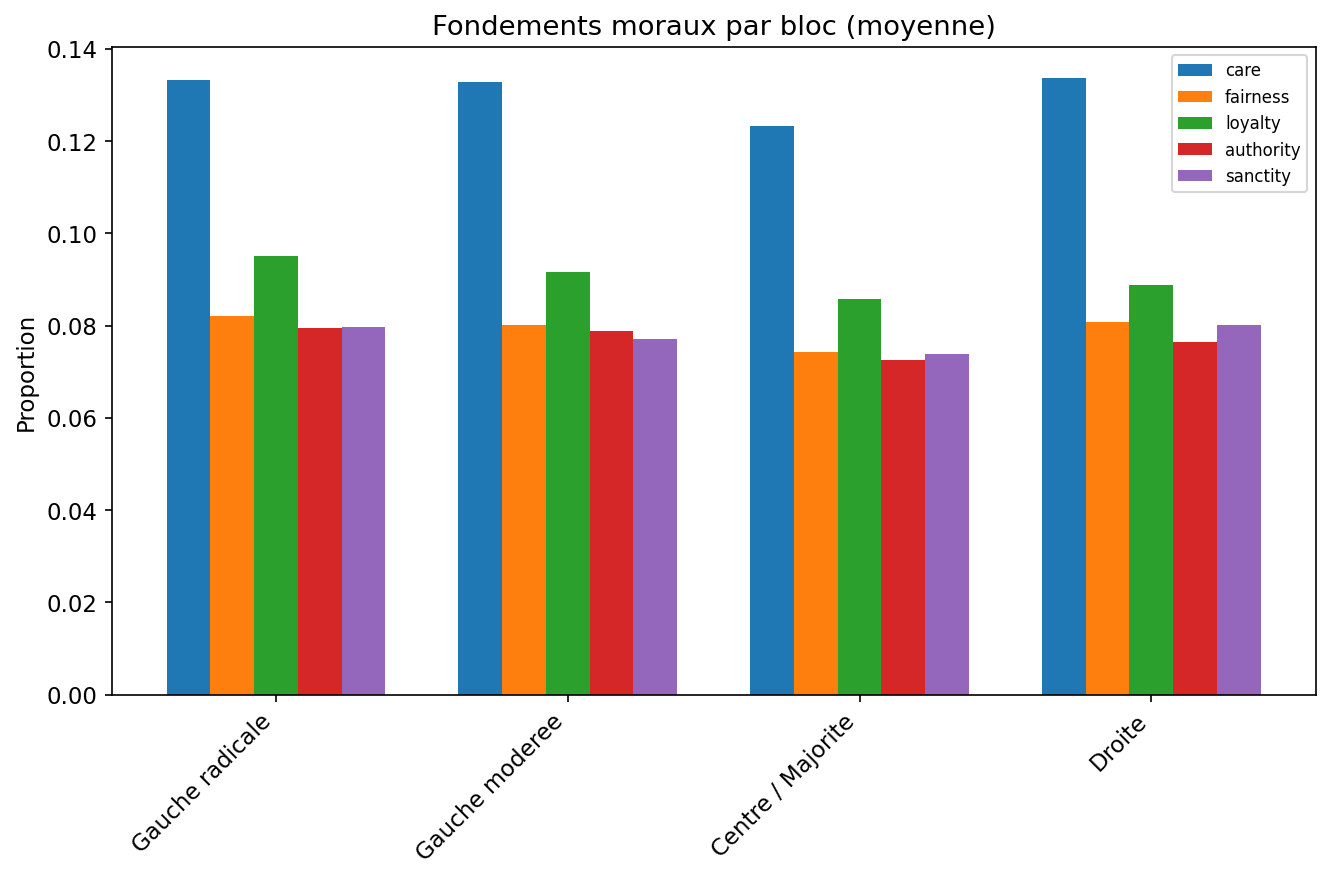

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_13992\2232026791.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


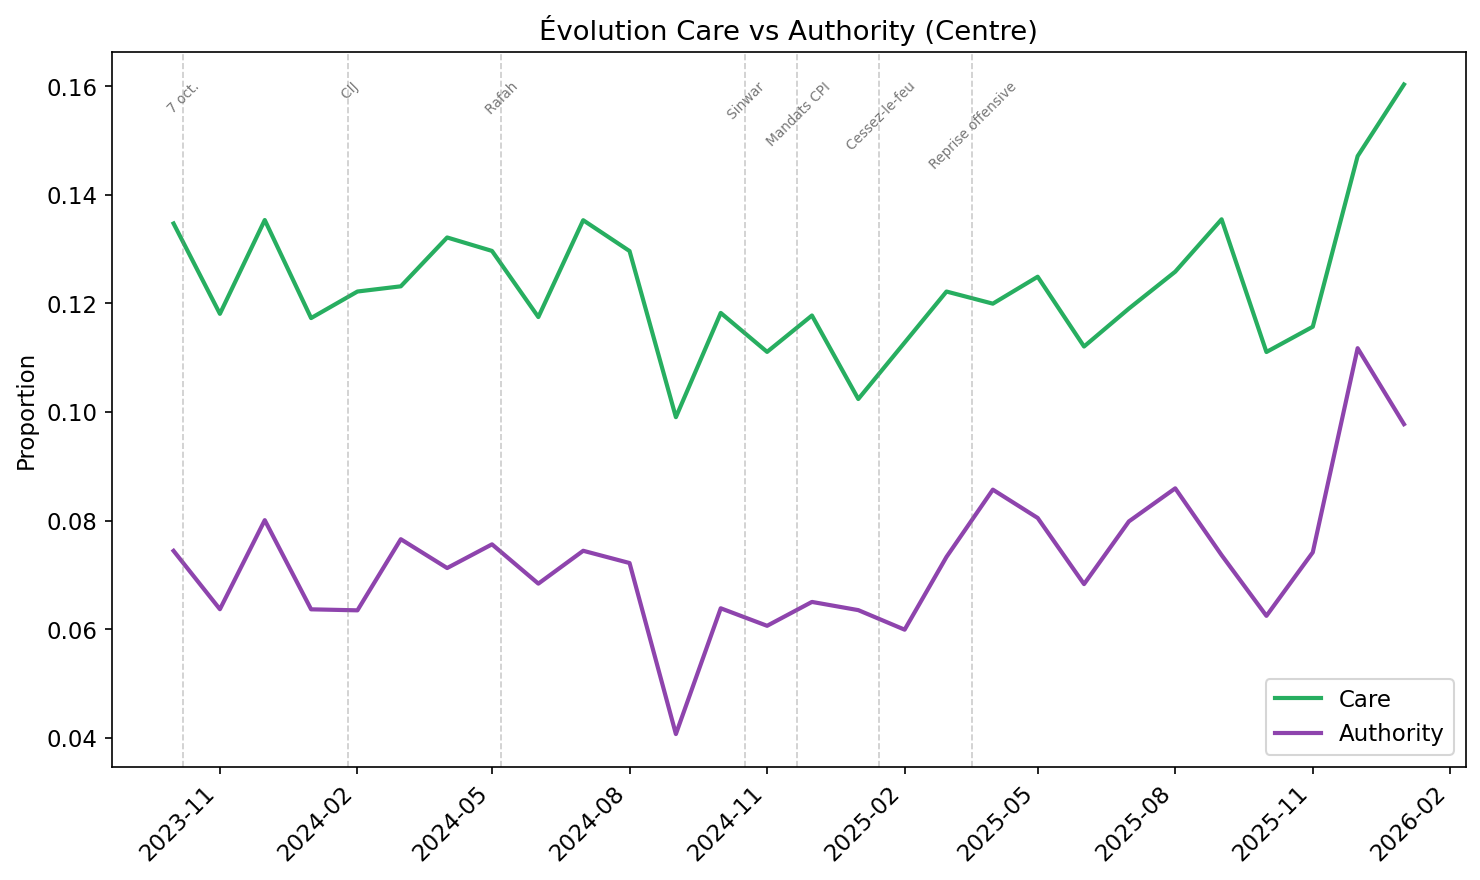

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_13992\2232026791.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


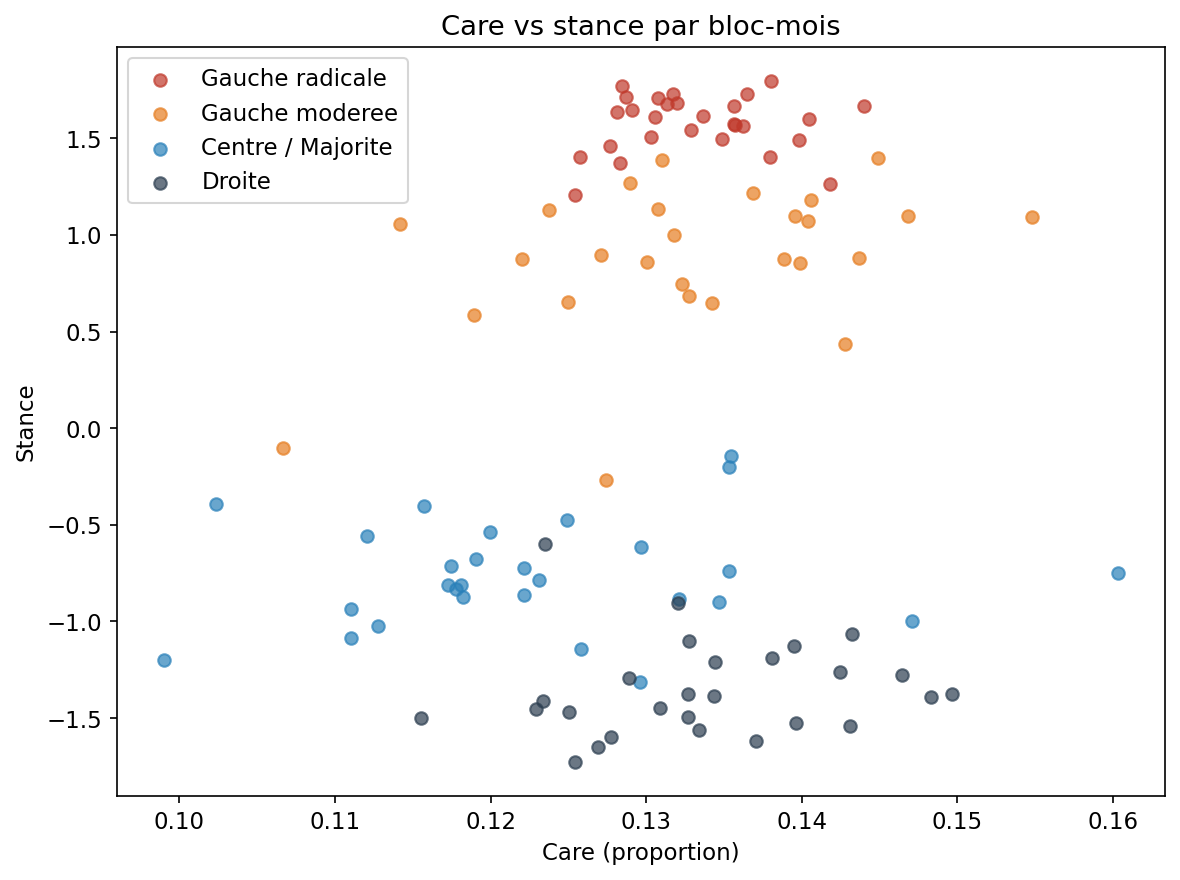

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
foundations = ['care', 'fairness', 'loyalty', 'authority', 'sanctity']
mfd_mean = mfd_bloc.groupby('bloc')[foundations].mean().reindex(BLOC_ORDER)
x = np.arange(len(BLOC_ORDER))
w = 0.15
for i, f in enumerate(foundations):
    vals = mfd_mean[f].values if len(mfd_mean) > 0 else [0]*len(BLOC_ORDER)
    ax.bar(x + i*w, vals, width=w, label=f)
ax.set_xticks(x + 2*w)
ax.set_xticklabels(BLOC_ORDER, rotation=45, ha='right')
ax.set_ylabel('Proportion')
ax.set_title('Fondements moraux par bloc (moyenne)')
ax.legend(fontsize=8)
plt.tight_layout()
save('fig59_moral_foundations_by_bloc')

fig, ax = plt.subplots(figsize=(10, 6))
centre = mfd_bloc[mfd_bloc['bloc'] == 'Centre / Majorite']
if len(centre) > 0:
    ax.plot(centre['month_ts'], centre['care'], label='Care', color='#27ae60', lw=2)
    ax.plot(centre['month_ts'], centre['authority'], label='Authority', color='#8e44ad', lw=2)
    add_events(ax)
    ax.set_ylabel('Proportion')
    ax.set_title('Évolution Care vs Authority (Centre)')
    ax.legend()
    format_dates(ax)
plt.tight_layout()
save('fig60_mfd_centre_care_authority')

fig, ax = plt.subplots(figsize=(8, 6))
stance_m = df_valid.groupby(['month', 'bloc'])['stance_v3'].mean().reset_index()
merge_mfd = mfd_bloc.merge(stance_m, on=['month', 'bloc'])
for bloc in BLOC_ORDER:
    sub = merge_mfd[merge_mfd['bloc'] == bloc]
    if len(sub) > 0:
        ax.scatter(sub['care'], sub['stance_v3'], label=bloc, color=BLOC_COLORS.get(bloc, '#888'), alpha=0.7)
ax.set_xlabel('Care (proportion)')
ax.set_ylabel('Stance')
ax.set_title('Care vs stance par bloc-mois')
ax.legend()
plt.tight_layout()
save('fig61_mfd_care_vs_stance')